<a href="https://colab.research.google.com/github/ULabanieh/Utrecht-Housing-Price-Predictor/blob/main/cla_project_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Utrecht Housing Price Predictor

## 📋 Project Overview
**Objective:** Predict Utrecht housing prices with 99%+ accuracy using physical features and location data
**Dataset:** 2,000 properties |
**Best Result:** €16,673 RMSE (99.40% R²)
**Key Innovation:** Hybrid categorical encoding strategy optimized per model type

In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The goal of the project is to explore how well housing prices can be predicted based on property characteristics and to build a clear end-to-end machine learning pipeline, from data exploration and preprocessing to model training and evaluation.

In [2]:
# Install libraries and dependancies for project
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn
!pip install torch

## 1️⃣ Setup & Dependencies
Importing core libraries for data analysis, visualization, and machine learning.

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import torch

In [4]:
# fix for scientific notation
pd.set_option("display.float_format", "{:,.0f}".format)

In [5]:
# setting random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [6]:
# establishing working directory
import os
os.chdir("/content/drive/MyDrive/Final Project/data")


Importing dataset from csv

In [7]:
df = pd.read_csv('/content/drive/MyDrive/Final Project/data/utrechthousinghuge.csv')
df

,id,zipcode,lot-len,lot-width,lot-area,house-area,garden-size,balcony,x-coor,y-coor,buildyear,bathrooms,taxvalue,retailvalue,energy-eff,monument
0,100426,3528,11,5,56,112,10,2,2112,5113,1932,1,494000,670000,0,1
1,100871,3528,14,5,68,112,8,0,2355,5218,1945,1,504000,675000,0,1
2,100936,3800,17,7,111,151,44,2,2656,5200,1946,1,692000,869000,0,1
3,100970,3800,19,6,112,108,40,2,2856,5201,1946,1,521000,628000,0,1
4,101191,3800,20,6,118,108,46,1,2962,5266,1950,1,526000,610000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,993057,3525,12,8,99,142,20,2,2252,5752,1990,2,648000,765000,1,0
1996,993131,3500,16,8,124,135,34,2,2650,5768,1992,1,639000,728000,0,0
1997,993444,3525,12,6,78,146,20,2,2204,5854,2000,2,647000,733000,1,0
1998,993873,3525,14,8,103,137,27,1,2352,5958,2015,2,629000,694000,1,0


In [8]:
df.shape

(2000, 16)

In [9]:
df.head()

,id,zipcode,lot-len,lot-width,lot-area,house-area,garden-size,balcony,x-coor,y-coor,buildyear,bathrooms,taxvalue,retailvalue,energy-eff,monument
0,100426,3528,11,5,56,112,10,2,2112,5113,1932,1,494000,670000,0,1
1,100871,3528,14,5,68,112,8,0,2355,5218,1945,1,504000,675000,0,1
2,100936,3800,17,7,111,151,44,2,2656,5200,1946,1,692000,869000,0,1
3,100970,3800,19,6,112,108,40,2,2856,5201,1946,1,521000,628000,0,1
4,101191,3800,20,6,118,108,46,1,2962,5266,1950,1,526000,610000,0,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           2000 non-null   int64  
 1   zipcode      2000 non-null   int64  
 2   lot-len      2000 non-null   float64
 3   lot-width    2000 non-null   float64
 4   lot-area     2000 non-null   float64
 5   house-area   2000 non-null   float64
 6   garden-size  2000 non-null   float64
 7   balcony      2000 non-null   int64  
 8   x-coor       2000 non-null   int64  
 9   y-coor       2000 non-null   int64  
 10  buildyear    2000 non-null   int64  
 11  bathrooms    2000 non-null   int64  
 12  taxvalue     2000 non-null   int64  
 13  retailvalue  2000 non-null   int64  
 14  energy-eff   2000 non-null   int64  
 15  monument     2000 non-null   int64  
dtypes: float64(5), int64(11)
memory usage: 250.1 KB


In [11]:
# duplicate check
df.nunique()

,0
id,1999
zipcode,4
lot-len,60
lot-width,61
lot-area,870
house-area,157
garden-size,652
balcony,3
x-coor,396
y-coor,398


In [12]:
print(df.duplicated().sum())

0


In [13]:
print(df['id'].duplicated().sum())

1


In [14]:
df[df['id'].duplicated(keep = False)]

,id,zipcode,lot-len,lot-width,lot-area,house-area,garden-size,balcony,x-coor,y-coor,buildyear,bathrooms,taxvalue,retailvalue,energy-eff,monument
947,531909,3800,15,9,137,202,47,2,2517,5467,1965,1,919000,1142000,0,1
948,531909,3800,15,8,122,109,49,2,2505,5462,1969,1,535000,693000,0,0


In [15]:
df[df.duplicated()]
# no duplicate records in this dataset

,id,zipcode,lot-len,lot-width,lot-area,house-area,garden-size,balcony,x-coor,y-coor,buildyear,bathrooms,taxvalue,retailvalue,energy-eff,monument


In [16]:
df.isnull().sum()

,0
id,0
zipcode,0
lot-len,0
lot-width,0
lot-area,0
house-area,0
garden-size,0
balcony,0
x-coor,0
y-coor,0


In [17]:
df.columns

Index(['id', 'zipcode', 'lot-len', 'lot-width', 'lot-area', 'house-area',
       'garden-size', 'balcony', 'x-coor', 'y-coor', 'buildyear', 'bathrooms',
       'taxvalue', 'retailvalue', 'energy-eff', 'monument'],
      dtype='object')

In [18]:
df['garden-size'].unique()

array([ 10.5,   8. ,  44.2,  39.6,  45.6,  48.4,  68.3,  85.5,   9.3,
        68.5,  89. ,  32.4,  83.3,   6.6,  11.9,  17.4,  48.9,   8.9,
        60.7,  55.6,  51. ,  20.3,  29.7,   5.1,  21. ,  70. ,  15.8,
        56.1,  44.7,  10.1,  14.6,  29.1,  77. ,  24.7,  43.4,   8.5,
        65.5,  14.3,  75.8,  20.2,   5.7,  30.4,  46.4,  26.2,  79.2,
         9.2,  96.6,  41.4,  17.8,  40.8,  38.9,   6.2,   9.1,   7.5,
        82.1,   8.8,  10.6,  12.4,  19.2,  23.1,  20. ,  83.4,  30.6,
         7.7,  20.5,  11.1,  50.9,   5.6,  27. ,  64.3,  35.2,  31.8,
        44.8,   8.7,  99.6,  10.3,  73.6,  64. ,  29. ,  57.5,  67.7,
        69.8,  25.5,  47.1,  45.4,  36.5,   7. ,  24. ,  23.4,  23. ,
        53. ,   5.2,  24.3,  15.9,  29.2,  47.8,  60.8,  73. ,  44. ,
        79.8,  35.3,  27.5,   8.3, 108.1,  42.7,  25.7,  63.7,  19.5,
        28.1,  42.6,  34.8,  37.8,  41.8,   6.7,   6.4,  51.9,  13.1,
        74.4,   9. ,  46. ,  59.2,  45.5,   6.9,  23.8,  21.6,  39.8,
        12.8,  68. ,

In [19]:
df['zipcode'].unique()

array([3528, 3800, 3525, 3500])

## 3️⃣ Location Feature Engineering
### Neighborhood Mapping
Dutch postcodes are hyper-local (10-20 houses each). The dataset contains listings in 4 neighborhoods:
| Postcode | Neighborhood              | Character              | % of Dataset |
|----------|---------------------------|------------------------|--------------|
| 3500     | Binnenstad                | Historic city center   | 18%          |
| 3525     | Tolsteeg                  | Residential area       | 25%          |
| 3528     | Kanaleneiland/Transwijk   | Suburban               | 25%          |
| 3800     | Amersfoort                | Nearby city            | 32%          |

**Impact:** Same 150 m² house can vary by €450k across neighborhoods!

In [20]:
# Postcode → Neighborhood mapping
df["zipcode"] = df["zipcode"].astype(str).str.strip()

zipcode_to_neighborhood = {
    "3528": "Kanaleneiland/Transwijk",
    "3525": "Tolsteeg",
    "3500": "Binnenstad",
    "3800": "Amersfoort"
}

# Create neighborhood column
df["neighborhood"] = df["zipcode"].map(zipcode_to_neighborhood)

print(df[["zipcode", "neighborhood"]].head())

print("-------------------------------------------------")
print()
# Create summary table
summary = df["neighborhood"].value_counts().reset_index()

summary.columns = ["neighborhood", "count"]

# Calculate percentage
summary["percentage"] = (
    summary["count"] / summary["count"].sum() * 100
)

# Format percentage with % sign
summary["percentage"] = summary["percentage"].round(0).astype(str) + "%"

print("Count Summary(zipcode)", )
print(summary)

  zipcode             neighborhood
0    3528  Kanaleneiland/Transwijk
1    3528  Kanaleneiland/Transwijk
2    3800               Amersfoort
3    3800               Amersfoort
4    3800               Amersfoort
-------------------------------------------------

Count Summary(zipcode)
              neighborhood  count percentage
0               Amersfoort    639      32.0%
1                 Tolsteeg    508      25.0%
2  Kanaleneiland/Transwijk    492      25.0%
3               Binnenstad    361      18.0%


In [21]:
df = df.drop(['id', 'lot-len', 'lot-width'], axis = 1)
df

,zipcode,lot-area,house-area,garden-size,balcony,x-coor,y-coor,buildyear,bathrooms,taxvalue,retailvalue,energy-eff,monument,neighborhood
0,3528,56,112,10,2,2112,5113,1932,1,494000,670000,0,1,Kanaleneiland/Transwijk
1,3528,68,112,8,0,2355,5218,1945,1,504000,675000,0,1,Kanaleneiland/Transwijk
2,3800,111,151,44,2,2656,5200,1946,1,692000,869000,0,1,Amersfoort
3,3800,112,108,40,2,2856,5201,1946,1,521000,628000,0,1,Amersfoort
4,3800,118,108,46,1,2962,5266,1950,1,526000,610000,0,1,Amersfoort
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3525,99,142,20,2,2252,5752,1990,2,648000,765000,1,0,Tolsteeg
1996,3500,124,135,34,2,2650,5768,1992,1,639000,728000,0,0,Binnenstad
1997,3525,78,146,20,2,2204,5854,2000,2,647000,733000,1,0,Tolsteeg
1998,3525,103,137,27,1,2352,5958,2015,2,629000,694000,1,0,Tolsteeg


In [22]:
df = df.rename(columns={ 'lot-area': 'lot_area', 'house-area': 'house_area', 'garden-side': 'garden_size', 'x-coor': 'x_coor', 'y-coor': 'y_coor', 'energy-eff': 'energy_eff', 'garden-size': 'garden_size', 'buildyear': 'build_year', 'taxvalue': 'tax_value', 'retailvalue': 'retail_value' })

In [23]:
df

,zipcode,lot_area,house_area,garden_size,balcony,x_coor,y_coor,build_year,bathrooms,tax_value,retail_value,energy_eff,monument,neighborhood
0,3528,56,112,10,2,2112,5113,1932,1,494000,670000,0,1,Kanaleneiland/Transwijk
1,3528,68,112,8,0,2355,5218,1945,1,504000,675000,0,1,Kanaleneiland/Transwijk
2,3800,111,151,44,2,2656,5200,1946,1,692000,869000,0,1,Amersfoort
3,3800,112,108,40,2,2856,5201,1946,1,521000,628000,0,1,Amersfoort
4,3800,118,108,46,1,2962,5266,1950,1,526000,610000,0,1,Amersfoort
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3525,99,142,20,2,2252,5752,1990,2,648000,765000,1,0,Tolsteeg
1996,3500,124,135,34,2,2650,5768,1992,1,639000,728000,0,0,Binnenstad
1997,3525,78,146,20,2,2204,5854,2000,2,647000,733000,1,0,Tolsteeg
1998,3525,103,137,27,1,2352,5958,2015,2,629000,694000,1,0,Tolsteeg


In [24]:
# verifying binary columns are truly binary
df["energy_eff"].unique()


array([0, 1])

In [25]:
df["monument"].unique()


array([1, 0])

In [26]:
# covert tax_value and retail_value features to int
df["retail_value"].head()


,retail_value
0,670000
1,675000
2,869000
3,628000
4,610000


In [27]:
df["tax_value"] = df["tax_value"].round(0).astype(int)
df["retail_value"] = df["retail_value"].round(0).astype(int)
df

,zipcode,lot_area,house_area,garden_size,balcony,x_coor,y_coor,build_year,bathrooms,tax_value,retail_value,energy_eff,monument,neighborhood
0,3528,56,112,10,2,2112,5113,1932,1,494000,670000,0,1,Kanaleneiland/Transwijk
1,3528,68,112,8,0,2355,5218,1945,1,504000,675000,0,1,Kanaleneiland/Transwijk
2,3800,111,151,44,2,2656,5200,1946,1,692000,869000,0,1,Amersfoort
3,3800,112,108,40,2,2856,5201,1946,1,521000,628000,0,1,Amersfoort
4,3800,118,108,46,1,2962,5266,1950,1,526000,610000,0,1,Amersfoort
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3525,99,142,20,2,2252,5752,1990,2,648000,765000,1,0,Tolsteeg
1996,3500,124,135,34,2,2650,5768,1992,1,639000,728000,0,0,Binnenstad
1997,3525,78,146,20,2,2204,5854,2000,2,647000,733000,1,0,Tolsteeg
1998,3525,103,137,27,1,2352,5958,2015,2,629000,694000,1,0,Tolsteeg


In [28]:
df[["tax_value", "retail_value"]].dtypes

,0
tax_value,int64
retail_value,int64


In [29]:
df[['lot_area', 'house_area', 'garden_size', 'build_year', 'tax_value', 'retail_value']].describe()

,lot_area,house_area,garden_size,build_year,tax_value,retail_value
count,"2,000","2,000","2,000","2,000","2,000","2,000"
mean,115,140,35,"1,969","651,715","791,024"
std,34,42,24,26,"182,927","210,980"
min,50,68,5,"1,920","310,000","419,000"
25%,89,111,14,"1,947","521,000","631,750"
50%,110,135,32,"1,969","633,000","766,000"
75%,138,166,53,"1,992","759,250","907,250"
max,216,248,116,"2,018","1,162,000","1,428,000"


In [30]:
df[['lot_area', 'house_area', 'garden_size', 'build_year', 'tax_value', 'retail_value']].skew()


,0
lot_area,1
house_area,1
garden_size,1
build_year,0
tax_value,1
retail_value,1


# Visualizations 1

In [31]:
# Style for nice-looking plots
sns.set_style("whitegrid")
%matplotlib inline

In [32]:
import matplotlib.ticker as mticker
from matplotlib.ticker import FixedLocator, FixedFormatter

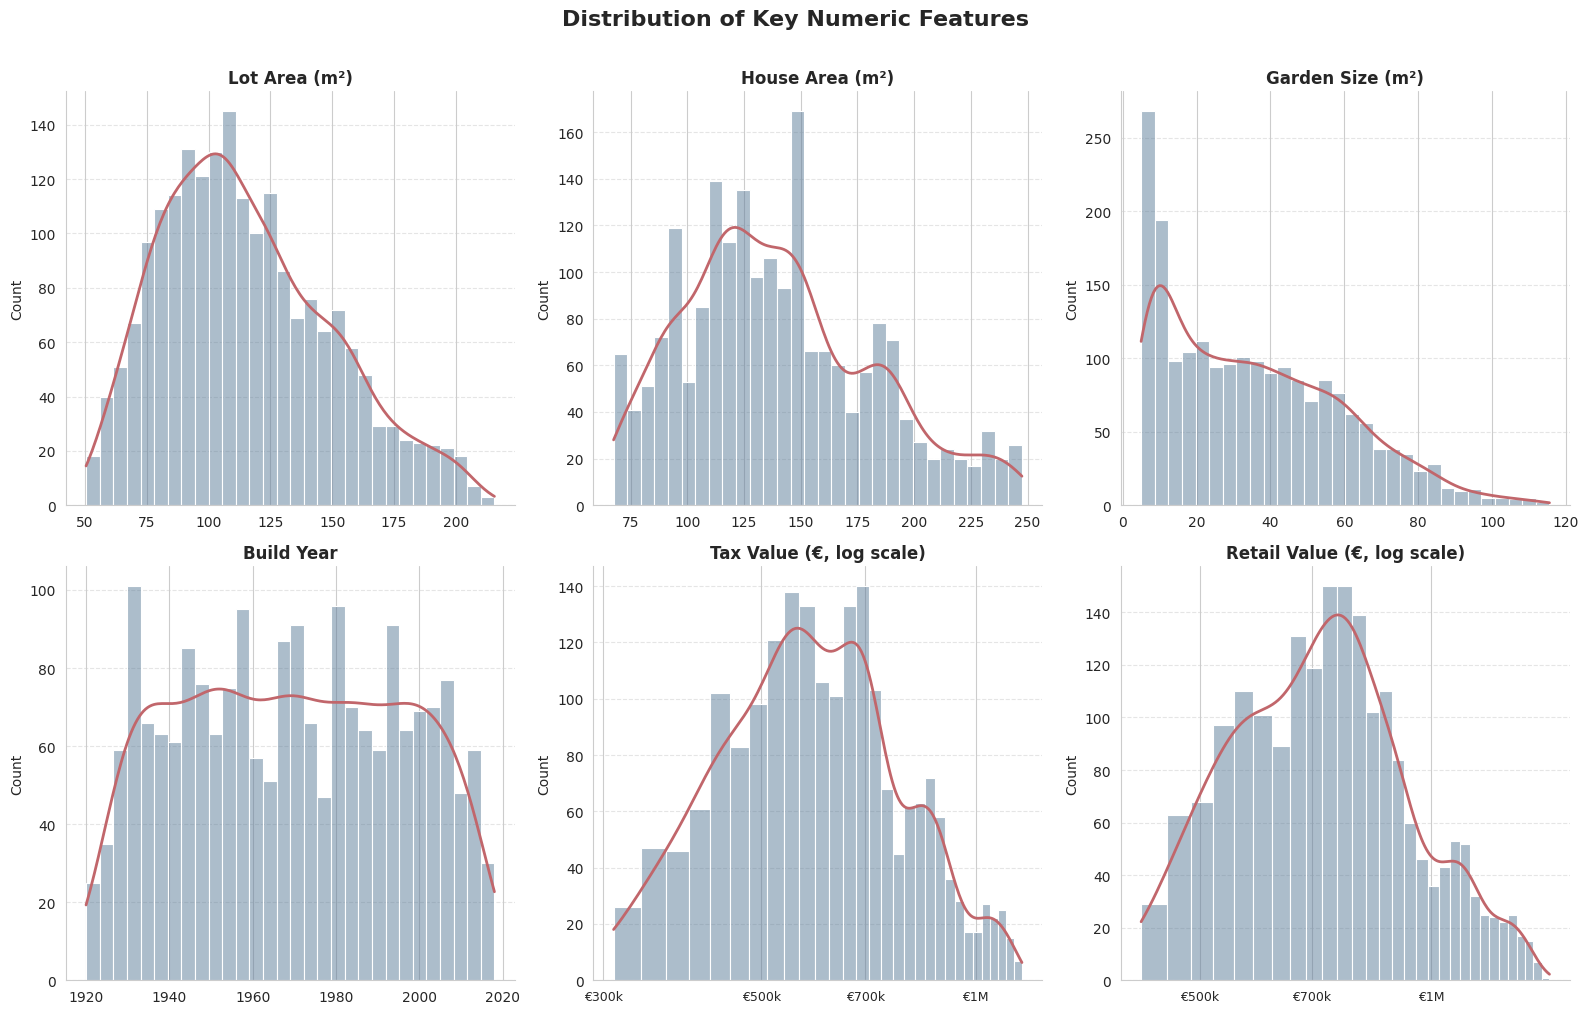

In [33]:
# Distributions of key numeric features

numeric_cols = ["lot_area", "house_area", "garden_size", "build_year", "tax_value", "retail_value"]

col_labels = {
    "lot_area": "Lot Area (m²)",
    "house_area": "House Area (m²)",
    "garden_size": "Garden Size (m²)",
    "build_year": "Build Year",
    "tax_value": "Tax Value (€, log scale)",
    "retail_value": "Retail Value (€, log scale)"
}

log_cols = {"tax_value", "retail_value"}

bar_color = "#5B7C99"  # Slate blue
kde_color = "#C1666B"  # Muted crimson

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribution of Key Numeric Features", fontsize=16, fontweight="bold", y=1.01)

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, color=bar_color, ax=ax)

    # Change KDE line color manually
    for line in ax.lines:
        line.set_color(kde_color)
        line.set_linewidth(2)

    if col in log_cols:
        ax.set_xscale("log")

        tick_values = [300000, 500000, 700000, 1000000]
        tick_labels = ["€300k", "€500k", "€700k", "€1M"]

        ax.xaxis.set_major_locator(FixedLocator(tick_values))
        ax.xaxis.set_major_formatter(FixedFormatter(tick_labels))
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.tick_params(axis='x', labelsize=9)

    ax.set_title(col_labels[col], fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

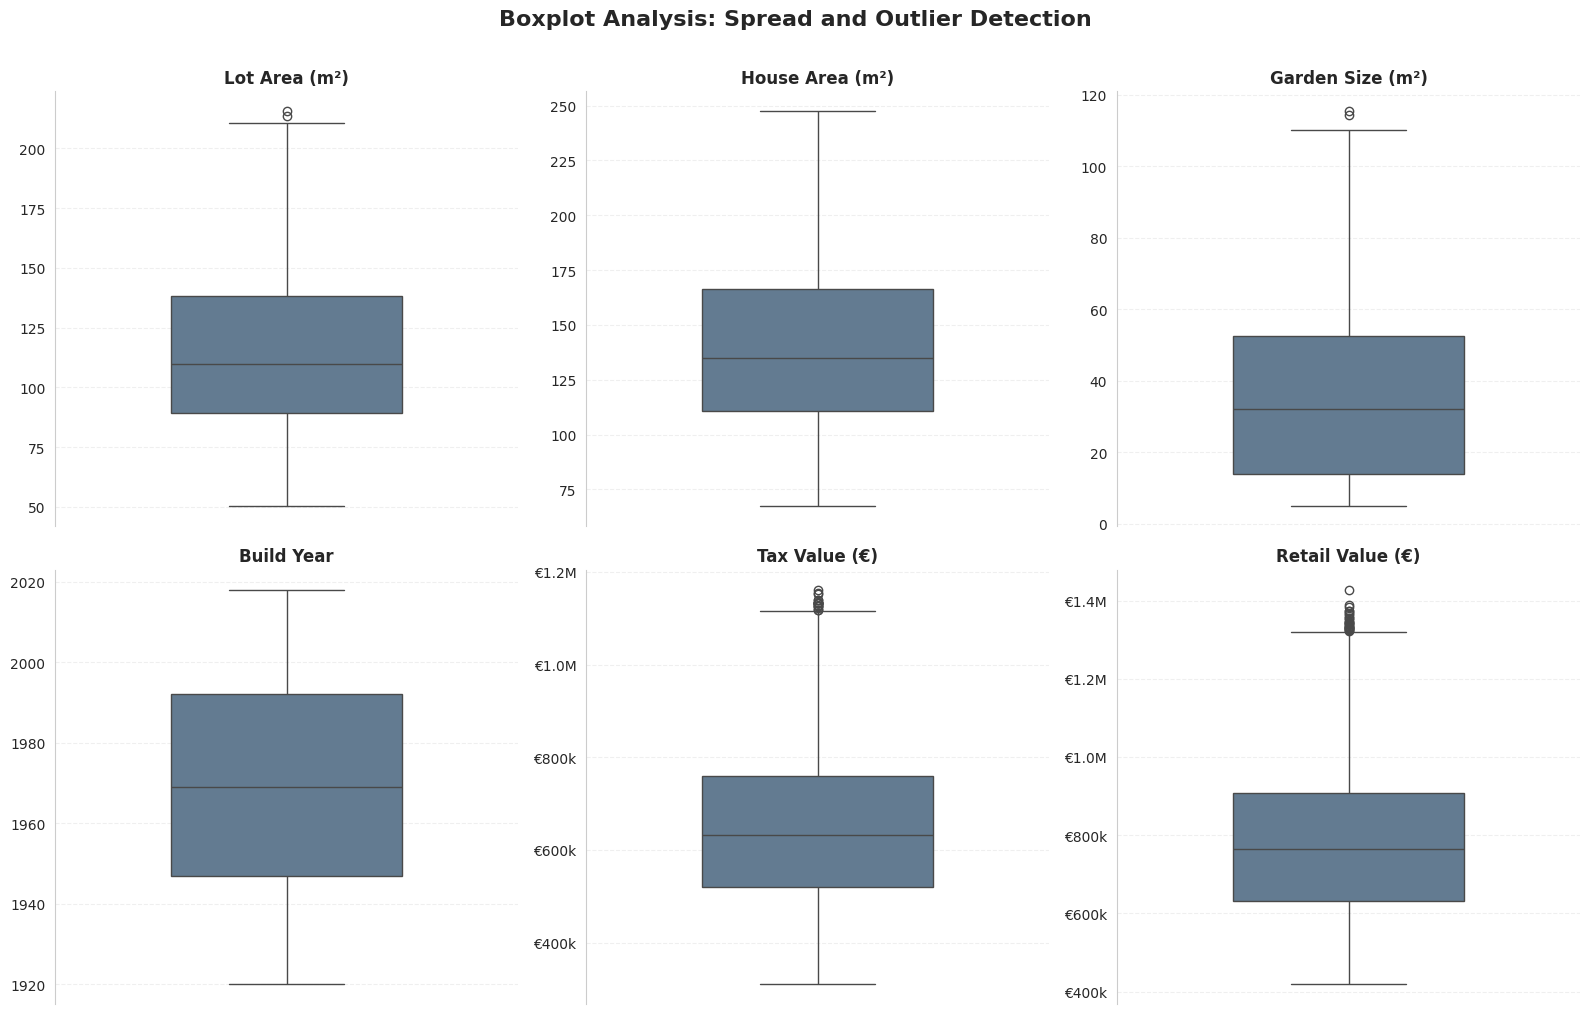

In [34]:
# Boxplots to highlight spread and potential outliers

numeric_cols = ["lot_area", "house_area", "garden_size", "build_year", "tax_value", "retail_value"]

col_labels = {
    "lot_area": "Lot Area (m²)",
    "house_area": "House Area (m²)",
    "garden_size": "Garden Size (m²)",
    "build_year": "Build Year",
    "tax_value": "Tax Value (€)",
    "retail_value": "Retail Value (€)"
}

log_cols = {"tax_value", "retail_value"}

box_color = "#5B7C99"  # Matching slate blue from distribution plots

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Boxplot Analysis: Spread and Outlier Detection", fontsize=16, fontweight="bold", y=1.01)

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], color=box_color, ax=ax, width=0.5)

    # Format y-axis for monetary values
    if col in log_cols:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{int(x/1000)}k" if x < 1000000 else f"€{x/1000000:.1f}M"))

    ax.set_title(col_labels[col], fontsize=12, fontweight="bold")
    ax.set_ylabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines[["top", "right", "bottom"]].set_visible(False)

plt.tight_layout()
plt.show()

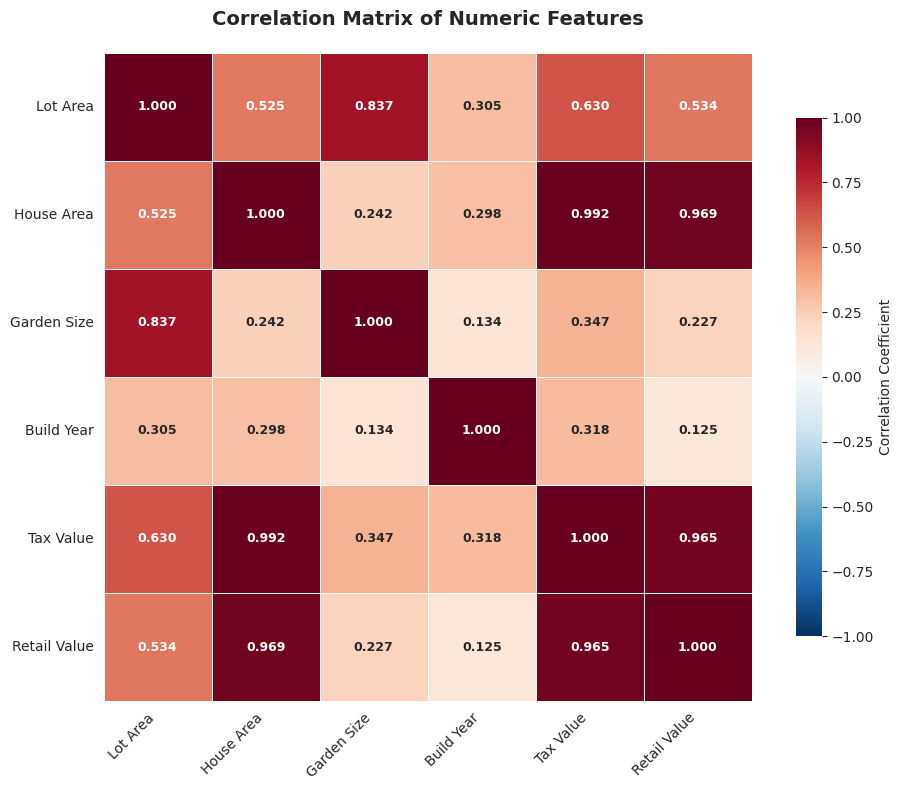

In [35]:
# Correlation heatmap
import matplotlib.ticker as mticker

numeric_cols = ["lot_area", "house_area", "garden_size", "build_year", "tax_value", "retail_value"]

col_labels = {
    "lot_area": "Lot Area",
    "house_area": "House Area",
    "garden_size": "Garden Size",
    "build_year": "Build Year",
    "tax_value": "Tax Value",
    "retail_value": "Retail Value"
}

# Calculate correlation matrix
corr = df[numeric_cols].corr()

# Rename columns and index for better readability
corr_display = corr.copy()
corr_display.columns = [col_labels[col] for col in corr_display.columns]
corr_display.index = [col_labels[col] for col in corr_display.index]

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap with custom styling
sns.heatmap(corr_display,
            annot=True,
            fmt=".3f",
            cmap="RdBu_r",  # Red-Blue diverging (red=positive, blue=negative)
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            annot_kws={"size": 9, "weight": "bold"},
            ax=ax)

# Styling
ax.set_title("Correlation Matrix of Numeric Features", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("")

# Rotate labels for better readability
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
from scipy.stats import skew

original_skew = skew(df["retail_value"])
log_skew = skew(np.log1p(df["retail_value"]))

print(f"Original Retail Value Skewness: {original_skew:.3f}")
print(f"Log-Transformed Skewness: {log_skew:.3f}")
print(f"Skewness Reduction: {((original_skew - log_skew) / original_skew * 100):.1f}%")

Original Retail Value Skewness: 0.615
Log-Transformed Skewness: 0.053
Skewness Reduction: 91.3%


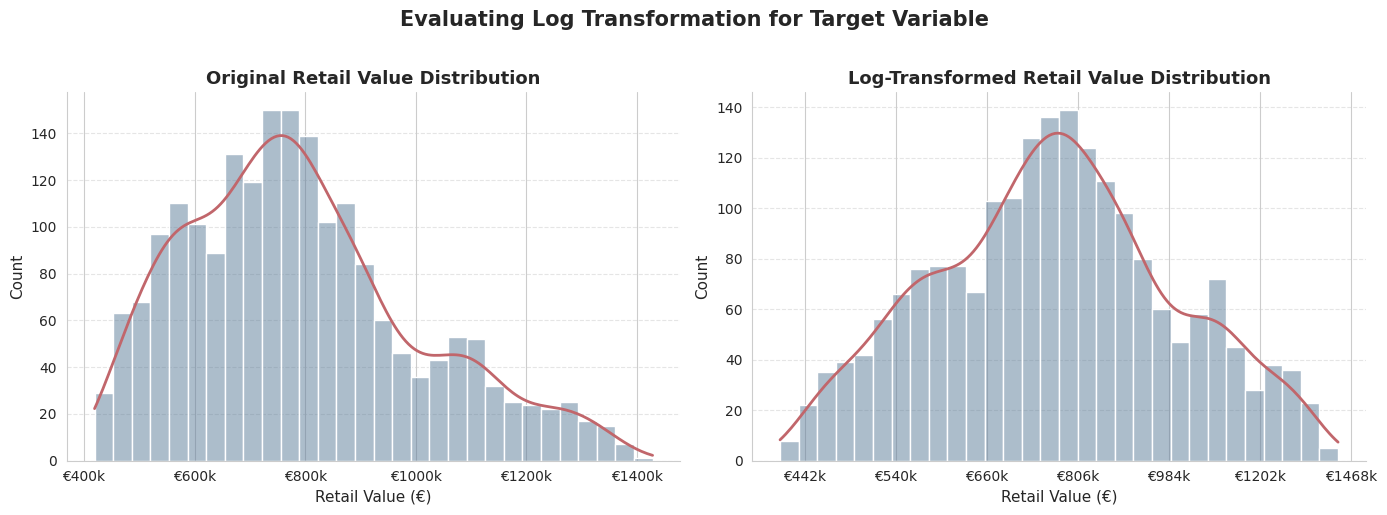

In [37]:
# Highlight skew and log transformation need

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_color = "#5B7C99"  # Slate blue
kde_color = "#C1666B"  # Muted crimson

# Original distribution
sns.histplot(df["retail_value"], bins=30, kde=True, color=bar_color, ax=axes[0])
for line in axes[0].lines:
    line.set_color(kde_color)
    line.set_linewidth(2)

axes[0].set_title("Original Retail Value Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Retail Value (€)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{int(x/1000)}k"))
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].spines[["top", "right"]].set_visible(False)

# Log-transformed distribution
log_values = np.log1p(df["retail_value"])
sns.histplot(log_values, bins=30, kde=True, color=bar_color, ax=axes[1])
for line in axes[1].lines:
    line.set_color(kde_color)
    line.set_linewidth(2)

axes[1].set_title("Log-Transformed Retail Value Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Retail Value (€)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)

# Convert log scale back to euros for x-axis labels
def log_to_euro(x, _):
    original_value = np.expm1(x)
    return f"€{int(original_value/1000)}k"

axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(log_to_euro))
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].spines[["top", "right"]].set_visible(False)

# Add overall title
fig.suptitle("Evaluating Log Transformation for Target Variable", fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

# Categorical Data Encoding, Feature Scalaing and Train-Test Split

## Hybrid Encoding Strategy for Categorical Features

Different machine learning models have different assumptions about data. This section implements a **hybrid encoding approach** that optimizes preprocessing for each model type.

**The approach:**
- **Tree models** (Random Forest, Gradient Boosting): Use label encoding (neighborhood → 0, 1, 2, 3)
- **Linear models** (Linear Regression, Neural Network): Use one-hot encoding (3 binary dummy variables)

**Why this matters:**
- Label encoding creates false ordering for linear models (model thinks 3 > 2 > 1)
- One-hot encoding creates unnecessary features for tree models (trees handle integers naturally)
- Result: Each model gets preprocessing optimized for its assumptions

**Data preparation scenarios:**
1. WITHOUT tax_value: Tests model with physical features + location only
2. WITH tax_value: Tests whether tax assessments add predictive value

This allows us to compare model performance and detect potential target leakage.

In [38]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

print("FEATURE PREPARATION & TRAIN-TEST SPLIT")
print("-" * 60)

# Categorical Encoding - Two Approaches

# Label Encoding for Tree Models
label_encoder = LabelEncoder()
df['neighborhood_label'] = label_encoder.fit_transform(df['neighborhood'])

print("\nLabel Encoding Mapping:")
for i, neighborhood in enumerate(label_encoder.classes_):
    print(f"  {i}: {neighborhood}")

# One-Hot Encoding for Linear/NN Models
neighborhood_dummies = pd.get_dummies(df['neighborhood'], prefix='neighborhood', drop_first=True)
df_with_dummies = pd.concat([df, neighborhood_dummies], axis=1)
neighborhood_cols = neighborhood_dummies.columns.tolist()

print(f"\nOne-Hot Encoded Features: {neighborhood_cols}")

# Define Feature Sets

base_features = ['lot_area', 'house_area', 'garden_size', 'build_year',
                 'bathrooms', 'energy_eff', 'monument']

# Tree Models
features_tree_no_tax = base_features + ['neighborhood_label']
features_tree_with_tax = features_tree_no_tax + ['tax_value']

# Linear/NN Models
features_linear_no_tax = base_features + neighborhood_cols
features_linear_with_tax = features_linear_no_tax + ['tax_value']

print("\nFeature Summary:")
print(f"  Tree models (no tax): {len(features_tree_no_tax)} features")
print(f"    {features_tree_no_tax}")
print(f"  Tree models (with tax): {len(features_tree_with_tax)} features")
print(f"  Linear/NN models (no tax): {len(features_linear_no_tax)} features")
print(f"  Linear/NN models (with tax): {len(features_linear_with_tax)} features")

# Create Feature Matrices

target = 'retail_value'

X_tree_no_tax = df[features_tree_no_tax]
X_tree_with_tax = df[features_tree_with_tax]

X_linear_no_tax = df_with_dummies[features_linear_no_tax]
X_linear_with_tax = df_with_dummies[features_linear_with_tax]

y = df[target]

# Train-Test Split

print("\nTrain-Test Split (80/20):")

X_train_tree_no_tax, X_test_tree_no_tax, y_train, y_test = train_test_split(
    X_tree_no_tax, y, test_size=0.2, random_state=42
)

X_train_tree_with_tax, X_test_tree_with_tax, _, _ = train_test_split(
    X_tree_with_tax, y, test_size=0.2, random_state=42
)

X_train_linear_no_tax, X_test_linear_no_tax, _, _ = train_test_split(
    X_linear_no_tax, y, test_size=0.2, random_state=42
)

X_train_linear_with_tax, X_test_linear_with_tax, _, _ = train_test_split(
    X_linear_with_tax, y, test_size=0.2, random_state=42
)

print(f"  Training samples: {len(y_train)}")
print(f"  Test samples: {len(y_test)}")

# Target Transformation

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Feature Scaling (Linear/NN only)

print("\nFeature Scaling:")

scaler_linear_no_tax = StandardScaler()
scaler_linear_with_tax = StandardScaler()

X_train_scaled_linear_no_tax = scaler_linear_no_tax.fit_transform(X_train_linear_no_tax)
X_test_scaled_linear_no_tax = scaler_linear_no_tax.transform(X_test_linear_no_tax)

X_train_scaled_linear_with_tax = scaler_linear_with_tax.fit_transform(X_train_linear_with_tax)
X_test_scaled_linear_with_tax = scaler_linear_with_tax.transform(X_test_linear_with_tax)

print(f"  Scaled linear data: {X_train_scaled_linear_no_tax.shape}")

# Summary

print("\nData Preparation Summary:")
print("-" * 60)

summary_data = {
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Neural Network'],
    'Training Data (no tax)': [
        'X_train_scaled_linear_no_tax',
        'X_train_tree_no_tax',
        'X_train_tree_no_tax',
        'X_train_scaled_linear_no_tax'
    ],
    'Target': ['y_train_log', 'y_train', 'y_train', 'y_train_log'],
    'Features': [
        len(features_linear_no_tax),
        len(features_tree_no_tax),
        len(features_tree_no_tax),
        len(features_linear_no_tax)
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\nData ready for model training.")

FEATURE PREPARATION & TRAIN-TEST SPLIT
------------------------------------------------------------

Label Encoding Mapping:
  0: Amersfoort
  1: Binnenstad
  2: Kanaleneiland/Transwijk
  3: Tolsteeg

One-Hot Encoded Features: ['neighborhood_Binnenstad', 'neighborhood_Kanaleneiland/Transwijk', 'neighborhood_Tolsteeg']

Feature Summary:
  Tree models (no tax): 8 features
    ['lot_area', 'house_area', 'garden_size', 'build_year', 'bathrooms', 'energy_eff', 'monument', 'neighborhood_label']
  Tree models (with tax): 9 features
  Linear/NN models (no tax): 10 features
  Linear/NN models (with tax): 11 features

Train-Test Split (80/20):
  Training samples: 1600
  Test samples: 400

Feature Scaling:
  Scaled linear data: (1600, 10)

Data Preparation Summary:
------------------------------------------------------------
            Model       Training Data (no tax)      Target  Features
Linear Regression X_train_scaled_linear_no_tax y_train_log        10
    Random Forest          X_train_t

# Linear Regression Model

## 6️⃣ Model 1: Linear Regression
**Preprocessing:** One-hot neighborhoods, scaled features, log-transformed target<br>
**Strengths:** Fast, interpretable, excellent baseline

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("LINEAR REGRESSION - MODEL TRAINING\n")

# Scenario 1: WITHOUT tax_value
print("Scenario 1: WITHOUT tax_value")

lr_no_tax = LinearRegression()
lr_no_tax.fit(X_train_scaled_linear_no_tax, y_train_log)

# Make predictions
y_train_pred_log_no_tax = lr_no_tax.predict(X_train_scaled_linear_no_tax)
y_test_pred_log_no_tax = lr_no_tax.predict(X_test_scaled_linear_no_tax)

# Back-transform to original scale
y_train_pred_no_tax = np.expm1(y_train_pred_log_no_tax)
y_test_pred_no_tax = np.expm1(y_test_pred_log_no_tax)

# Calculate metrics
train_rmse_no_tax = np.sqrt(mean_squared_error(y_train, y_train_pred_no_tax))
test_rmse_no_tax = np.sqrt(mean_squared_error(y_test, y_test_pred_no_tax))
train_mae_no_tax = mean_absolute_error(y_train, y_train_pred_no_tax)
test_mae_no_tax = mean_absolute_error(y_test, y_test_pred_no_tax)
train_r2_no_tax = r2_score(y_train, y_train_pred_no_tax)
test_r2_no_tax = r2_score(y_test, y_test_pred_no_tax)

print(f"\nTraining Performance:")
print(f"  RMSE: €{train_rmse_no_tax:,.0f}")
print(f"  MAE:  €{train_mae_no_tax:,.0f}")
print(f"  R²:   {train_r2_no_tax:.4f}")

print(f"\nTest Performance:")
print(f"  RMSE: €{test_rmse_no_tax:,.0f}")
print(f"  MAE:  €{test_mae_no_tax:,.0f}")
print(f"  R²:   {test_r2_no_tax:.4f}")

# Scenario 2: WITH tax_value
print("\n\nScenario 2: WITH tax_value")

lr_with_tax = LinearRegression()
lr_with_tax.fit(X_train_scaled_linear_with_tax, y_train_log)

y_train_pred_log_with_tax = lr_with_tax.predict(X_train_scaled_linear_with_tax)
y_test_pred_log_with_tax = lr_with_tax.predict(X_test_scaled_linear_with_tax)

# Back-transform
y_train_pred_with_tax = np.expm1(y_train_pred_log_with_tax)
y_test_pred_with_tax = np.expm1(y_test_pred_log_with_tax)

# Calculate metrics
train_rmse_with_tax = np.sqrt(mean_squared_error(y_train, y_train_pred_with_tax))
test_rmse_with_tax = np.sqrt(mean_squared_error(y_test, y_test_pred_with_tax))
train_mae_with_tax = mean_absolute_error(y_train, y_train_pred_with_tax)
test_mae_with_tax = mean_absolute_error(y_test, y_test_pred_with_tax)
train_r2_with_tax = r2_score(y_train, y_train_pred_with_tax)
test_r2_with_tax = r2_score(y_test, y_test_pred_with_tax)

print(f"\nTraining Performance:")
print(f"  RMSE: €{train_rmse_with_tax:,.0f}")
print(f"  MAE:  €{train_mae_with_tax:,.0f}")
print(f"  R²:   {train_r2_with_tax:.4f}")

print(f"\nTest Performance:")
print(f"  RMSE: €{test_rmse_with_tax:,.0f}")
print(f"  MAE:  €{test_mae_with_tax:,.0f}")
print(f"  R²:   {test_r2_with_tax:.4f}")

print("\n✅ Linear Regression models trained successfully!")

LINEAR REGRESSION - MODEL TRAINING

Scenario 1: WITHOUT tax_value

Training Performance:
  RMSE: €36,427
  MAE:  €26,766
  R²:   0.9699

Test Performance:
  RMSE: €41,685
  MAE:  €28,513
  R²:   0.9623


Scenario 2: WITH tax_value

Training Performance:
  RMSE: €36,420
  MAE:  €26,766
  R²:   0.9699

Test Performance:
  RMSE: €41,661
  MAE:  €28,502
  R²:   0.9623

✅ Linear Regression models trained successfully!


# Tree based Models

## 7️⃣ Model 2: Random Forest
**Preprocessing:** Label-encoded neighborhood, no scaling<br>
**Hyperparameters:** 100 trees, max_depth=20<br>
**How it works:** 100 independent trees, each on random data subset, average predictions

In [40]:
from sklearn.ensemble import RandomForestRegressor

print("RANDOM FOREST - MODEL TRAINING\n")

# Scenario 1: WITHOUT tax_value
print("Scenario 1: WITHOUT tax_value")

rf_no_tax = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_no_tax.fit(X_train_tree_no_tax, y_train)

# Make predictions
y_train_pred_rf_no_tax = rf_no_tax.predict(X_train_tree_no_tax)
y_test_pred_rf_no_tax = rf_no_tax.predict(X_test_tree_no_tax)

# Calculate metrics
train_rmse_rf_no_tax = np.sqrt(mean_squared_error(y_train, y_train_pred_rf_no_tax))
test_rmse_rf_no_tax = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_no_tax))
train_mae_rf_no_tax = mean_absolute_error(y_train, y_train_pred_rf_no_tax)
test_mae_rf_no_tax = mean_absolute_error(y_test, y_test_pred_rf_no_tax)
train_r2_rf_no_tax = r2_score(y_train, y_train_pred_rf_no_tax)
test_r2_rf_no_tax = r2_score(y_test, y_test_pred_rf_no_tax)

print(f"\nTraining Performance:")
print(f"  RMSE: €{train_rmse_rf_no_tax:,.0f}")
print(f"  MAE:  €{train_mae_rf_no_tax:,.0f}")
print(f"  R²:   {train_r2_rf_no_tax:.4f}")

print(f"\nTest Performance:")
print(f"  RMSE: €{test_rmse_rf_no_tax:,.0f}")
print(f"  MAE:  €{test_mae_rf_no_tax:,.0f}")
print(f"  R²:   {test_r2_rf_no_tax:.4f}")

# Scenario 2: WITH tax_value
print("\n\nScenario 2: WITH tax_value")

rf_with_tax = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_with_tax.fit(X_train_tree_with_tax, y_train)

y_train_pred_rf_with_tax = rf_with_tax.predict(X_train_tree_with_tax)
y_test_pred_rf_with_tax = rf_with_tax.predict(X_test_tree_with_tax)

# Calculate metrics
train_rmse_rf_with_tax = np.sqrt(mean_squared_error(y_train, y_train_pred_rf_with_tax))
test_rmse_rf_with_tax = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_with_tax))
train_mae_rf_with_tax = mean_absolute_error(y_train, y_train_pred_rf_with_tax)
test_mae_rf_with_tax = mean_absolute_error(y_test, y_test_pred_rf_with_tax)
train_r2_rf_with_tax = r2_score(y_train, y_train_pred_rf_with_tax)
test_r2_rf_with_tax = r2_score(y_test, y_test_pred_rf_with_tax)

print(f"\nTraining Performance:")
print(f"  RMSE: €{train_rmse_rf_with_tax:,.0f}")
print(f"  MAE:  €{train_mae_rf_with_tax:,.0f}")
print(f"  R²:   {train_r2_rf_with_tax:.4f}")

print(f"\nTest Performance:")
print(f"  RMSE: €{test_rmse_rf_with_tax:,.0f}")
print(f"  MAE:  €{test_mae_rf_with_tax:,.0f}")
print(f"  R²:   {test_r2_rf_with_tax:.4f}")

# Feature importance
print("\n\nFEATURE IMPORTANCE ANALYSIS\n")

print("Scenario 1: Feature Importance (WITHOUT tax_value)")
feature_importance_rf_no_tax = pd.DataFrame({
    'Feature': features_tree_no_tax,  # ← CHANGED - now includes neighborhood_label
    'Importance': rf_no_tax.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"{'Feature':<20} {'Importance':<12} {'Percentage':<10}")
print("-" * 45)
for _, row in feature_importance_rf_no_tax.iterrows():
    print(f"{row['Feature']:<20} {row['Importance']:<12.6f} {row['Importance']*100:>8.2f}%")

print("\n\nScenario 2: Feature Importance (WITH tax_value)")
feature_importance_rf_with_tax = pd.DataFrame({
    'Feature': features_tree_with_tax,
    'Importance': rf_with_tax.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"{'Feature':<20} {'Importance':<12} {'Percentage':<10}")
print("-" * 45)
for _, row in feature_importance_rf_with_tax.iterrows():
    print(f"{row['Feature']:<20} {row['Importance']:<12.6f} {row['Importance']*100:>8.2f}%")

print("\n✅ Random Forest models trained successfully!")

RANDOM FOREST - MODEL TRAINING

Scenario 1: WITHOUT tax_value

Training Performance:
  RMSE: €10,065
  MAE:  €7,386
  R²:   0.9977

Test Performance:
  RMSE: €18,352
  MAE:  €14,094
  R²:   0.9927


Scenario 2: WITH tax_value

Training Performance:
  RMSE: €9,890
  MAE:  €7,211
  R²:   0.9978

Test Performance:
  RMSE: €18,184
  MAE:  €14,054
  R²:   0.9928


FEATURE IMPORTANCE ANALYSIS

Scenario 1: Feature Importance (WITHOUT tax_value)
Feature              Importance   Percentage
---------------------------------------------
house_area           0.952863        95.29%
build_year           0.038040         3.80%
lot_area             0.003526         0.35%
garden_size          0.002691         0.27%
monument             0.001618         0.16%
neighborhood_label   0.000775         0.08%
energy_eff           0.000362         0.04%
bathrooms            0.000126         0.01%


Scenario 2: Feature Importance (WITH tax_value)
Feature              Importance   Percentage
--------------------

## 8️⃣ Model 3: Gradient Boosting (BEST 🏆)
**Preprocessing:** Label-encoded neighborhood, no scaling<br>
**Hyperparameters:** 100 trees, learning_rate=0.1, max_depth=5, subsample=0.8<br>
**Why it wins:** Sequential error correction - each tree fixes mistakes of previous trees<br>
**Key difference from RF:** Sequential (boosting) vs Parallel (bagging)

In [41]:
from sklearn.ensemble import GradientBoostingRegressor

print("GRADIENT BOOSTING - MODEL TRAINING\n")

# Scenario 1: WITHOUT tax_value
print("Scenario 1: WITHOUT tax_value")

gb_no_tax = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

gb_no_tax.fit(X_train_tree_no_tax, y_train)
y_train_pred_gb_no_tax = gb_no_tax.predict(X_train_tree_no_tax)
y_test_pred_gb_no_tax = gb_no_tax.predict(X_test_tree_no_tax)

train_rmse_gb_no_tax = np.sqrt(mean_squared_error(y_train, y_train_pred_gb_no_tax))
test_rmse_gb_no_tax = np.sqrt(mean_squared_error(y_test, y_test_pred_gb_no_tax))
train_mae_gb_no_tax = mean_absolute_error(y_train, y_train_pred_gb_no_tax)
test_mae_gb_no_tax = mean_absolute_error(y_test, y_test_pred_gb_no_tax)
train_r2_gb_no_tax = r2_score(y_train, y_train_pred_gb_no_tax)
test_r2_gb_no_tax = r2_score(y_test, y_test_pred_gb_no_tax)

print(f"\nTraining Performance:")
print(f"  RMSE: €{train_rmse_gb_no_tax:,.0f}")
print(f"  MAE:  €{train_mae_gb_no_tax:,.0f}")
print(f"  R²:   {train_r2_gb_no_tax:.4f}")

print(f"\nTest Performance:")
print(f"  RMSE: €{test_rmse_gb_no_tax:,.0f}")
print(f"  MAE:  €{test_mae_gb_no_tax:,.0f}")
print(f"  R²:   {test_r2_gb_no_tax:.4f}")

# Scenario 2: WITH tax_value
print("\n\nScenario 2: WITH tax_value")

gb_with_tax = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

gb_with_tax.fit(X_train_tree_with_tax, y_train)
y_train_pred_gb_with_tax = gb_with_tax.predict(X_train_tree_with_tax)
y_test_pred_gb_with_tax = gb_with_tax.predict(X_test_tree_with_tax)

train_rmse_gb_with_tax = np.sqrt(mean_squared_error(y_train, y_train_pred_gb_with_tax))
test_rmse_gb_with_tax = np.sqrt(mean_squared_error(y_test, y_test_pred_gb_with_tax))
train_mae_gb_with_tax = mean_absolute_error(y_train, y_train_pred_gb_with_tax)
test_mae_gb_with_tax = mean_absolute_error(y_test, y_test_pred_gb_with_tax)
train_r2_gb_with_tax = r2_score(y_train, y_train_pred_gb_with_tax)
test_r2_gb_with_tax = r2_score(y_test, y_test_pred_gb_with_tax)

print(f"\nTraining Performance:")
print(f"  RMSE: €{train_rmse_gb_with_tax:,.0f}")
print(f"  MAE:  €{train_mae_gb_with_tax:,.0f}")
print(f"  R²:   {train_r2_gb_with_tax:.4f}")

print(f"\nTest Performance:")
print(f"  RMSE: €{test_rmse_gb_with_tax:,.0f}")
print(f"  MAE:  €{test_mae_gb_with_tax:,.0f}")
print(f"  R²:   {test_r2_gb_with_tax:.4f}")

# Feature importance
print("\n\nFEATURE IMPORTANCE ANALYSIS\n")

print("Scenario 1: Feature Importance (WITHOUT tax_value)")
feature_importance_gb_no_tax = pd.DataFrame({
    'Feature': features_tree_no_tax,
    'Importance': gb_no_tax.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"{'Feature':<15} {'Importance':<12} {'Percentage':<10}")
print("-" * 40)
for _, row in feature_importance_gb_no_tax.iterrows():
    print(f"{row['Feature']:<15} {row['Importance']:<12.6f} {row['Importance']*100:>8.2f}%")

print("\n\nScenario 2: Feature Importance (WITH tax_value)")
feature_importance_gb_with_tax = pd.DataFrame({
    'Feature': features_tree_with_tax,
    'Importance': gb_with_tax.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"{'Feature':<15} {'Importance':<12} {'Percentage':<10}")
print("-" * 40)
for _, row in feature_importance_gb_with_tax.iterrows():
    print(f"{row['Feature']:<15} {row['Importance']:<12.6f} {row['Importance']*100:>8.2f}%")

print("\n✅ Gradient Boosting models trained successfully!")

GRADIENT BOOSTING - MODEL TRAINING

Scenario 1: WITHOUT tax_value

Training Performance:
  RMSE: €9,517
  MAE:  €7,255
  R²:   0.9979

Test Performance:
  RMSE: €16,782
  MAE:  €12,964
  R²:   0.9939


Scenario 2: WITH tax_value

Training Performance:
  RMSE: €9,288
  MAE:  €7,115
  R²:   0.9980

Test Performance:
  RMSE: €16,673
  MAE:  €12,939
  R²:   0.9940


FEATURE IMPORTANCE ANALYSIS

Scenario 1: Feature Importance (WITHOUT tax_value)
Feature         Importance   Percentage
----------------------------------------
house_area      0.944330        94.43%
build_year      0.038875         3.89%
monument        0.004388         0.44%
energy_eff      0.004058         0.41%
lot_area        0.004035         0.40%
garden_size     0.002913         0.29%
neighborhood_label 0.001377         0.14%
bathrooms       0.000024         0.00%


Scenario 2: Feature Importance (WITH tax_value)
Feature         Importance   Percentage
----------------------------------------
house_area      0.688222    

# Neural Network

## 9️⃣ Model 4: Neural Network
**Architecture:** 10 → 16 → 8 → 1 (3 layers)<br>
**Regularization:** Dropout (20%), BatchNorm, Early Stopping<br>
**Why underperforms:** Insufficient data (need 10k+ samples for deep learning)<br>
**Key lesson:** Use tree models for small tabular datasets

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("NEURAL NETWORK - SIMPLIFIED ARCHITECTURE\n")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# Much simpler, shallower network
class HousingPriceNN(nn.Module):
    def __init__(self, input_size):
        super(HousingPriceNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.bn1 = nn.BatchNorm1d(16)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(16, 8)
        self.bn2 = nn.BatchNorm1d(8)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(8, 1)

        # Better weight initialization
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.bn1(x)
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.bn2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

def train_neural_network(X_train_scaled, y_train_log, X_test_scaled, y_test_log,
                         y_train_original, y_test_original, scenario_name, input_size):

    print(f"Scenario: {scenario_name}")

    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
    y_train_tensor = torch.FloatTensor(y_train_log.values).reshape(-1, 1).to(device)
    X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

    # Create DataLoader with larger batch size
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

    # Initialize model
    model = HousingPriceNN(input_size).to(device)

    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    # Training parameters
    n_epochs = 500
    best_loss = float('inf')
    patience = 50
    patience_counter = 0

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0

        for batch_X, batch_y in train_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        scheduler.step()

        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            model.load_state_dict(best_model_state)
            break

        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        y_train_pred_log = model(X_train_tensor).cpu().numpy().flatten()
        y_test_pred_log = model(X_test_tensor).cpu().numpy().flatten()

    # Back-transform to original scale
    y_train_pred = np.expm1(y_train_pred_log)
    y_test_pred = np.expm1(y_test_pred_log)

    # Clip negative predictions
    y_train_pred = np.maximum(y_train_pred, 0)
    y_test_pred = np.maximum(y_test_pred, 0)

    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_original, y_test_pred))
    train_mae = mean_absolute_error(y_train_original, y_train_pred)
    test_mae = mean_absolute_error(y_test_original, y_test_pred)
    train_r2 = r2_score(y_train_original, y_train_pred)
    test_r2 = r2_score(y_test_original, y_test_pred)

    print(f"\nTraining Performance:")
    print(f"  RMSE: €{train_rmse:,.0f}")
    print(f"  MAE:  €{train_mae:,.0f}")
    print(f"  R²:   {train_r2:.4f}")

    print(f"\nTest Performance:")
    print(f"  RMSE: €{test_rmse:,.0f}")
    print(f"  MAE:  €{test_mae:,.0f}")
    print(f"  R²:   {test_r2:.4f}\n")

    return {
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2
    }

# Train both scenarios
results_nn_no_tax = train_neural_network(
    X_train_scaled_linear_no_tax,
    y_train_log,
    X_test_scaled_linear_no_tax,
    y_test_log,
    y_train,
    y_test,
    "WITHOUT tax_value",
    input_size=len(features_linear_no_tax)
)

# WITH tax scenario
results_nn_with_tax = train_neural_network(
    X_train_scaled_linear_with_tax,
    y_train_log,
    X_test_scaled_linear_with_tax,
    y_test_log,
    y_train,
    y_test,
    "WITH tax_value",
    input_size=len(features_linear_with_tax)
)

# Comparison
print("=" * 60)
print("MODEL COMPARISON: All Models\n")

print("WITHOUT tax_value:")
print(f"{'Model':<20} {'Test RMSE':<15} {'Test MAE':<15} {'Test R²':<10}")
print("-" * 60)
print(f"{'Linear Regression':<20} €{test_rmse_no_tax:>13,.0f} €{test_mae_no_tax:>13,.0f} {test_r2_no_tax:>9.4f}")
print(f"{'Random Forest':<20} €{test_rmse_rf_no_tax:>13,.0f} €{test_mae_rf_no_tax:>13,.0f} {test_r2_rf_no_tax:>9.4f}")
print(f"{'Gradient Boosting':<20} €{test_rmse_gb_no_tax:>13,.0f} €{test_mae_gb_no_tax:>13,.0f} {test_r2_gb_no_tax:>9.4f}")
print(f"{'Neural Network':<20} €{results_nn_no_tax['test_rmse']:>13,.0f} €{results_nn_no_tax['test_mae']:>13,.0f} {results_nn_no_tax['test_r2']:>9.4f}")

print("\nWITH tax_value:")
print(f"{'Model':<20} {'Test RMSE':<15} {'Test MAE':<15} {'Test R²':<10}")
print("-" * 60)
print(f"{'Linear Regression':<20} €{test_rmse_with_tax:>13,.0f} €{test_mae_with_tax:>13,.0f} {test_r2_with_tax:>9.4f}")
print(f"{'Random Forest':<20} €{test_rmse_rf_with_tax:>13,.0f} €{test_mae_rf_with_tax:>13,.0f} {test_r2_rf_with_tax:>9.4f}")
print(f"{'Gradient Boosting':<20} €{test_rmse_gb_with_tax:>13,.0f} €{test_mae_gb_with_tax:>13,.0f} {test_r2_gb_with_tax:>9.4f}")
print(f"{'Neural Network':<20} €{results_nn_with_tax['test_rmse']:>13,.0f} €{results_nn_with_tax['test_mae']:>13,.0f} {results_nn_with_tax['test_r2']:>9.4f}")

print("\n✅ Neural Network models trained successfully!")

NEURAL NETWORK - SIMPLIFIED ARCHITECTURE

Using device: cpu

Scenario: WITHOUT tax_value
  Epoch 100/500, Loss: 0.804189
  Epoch 200/500, Loss: 0.255055
  Epoch 300/500, Loss: 0.191839
  Early stopping at epoch 391

Training Performance:
  RMSE: €66,630
  MAE:  €56,319
  R²:   0.8993

Test Performance:
  RMSE: €65,174
  MAE:  €55,249
  R²:   0.9078

Scenario: WITH tax_value
  Epoch 100/500, Loss: 0.757567
  Epoch 200/500, Loss: 0.209122
  Epoch 300/500, Loss: 0.150715
  Epoch 400/500, Loss: 0.132257
  Epoch 500/500, Loss: 0.129059

Training Performance:
  RMSE: €56,120
  MAE:  €46,099
  R²:   0.9286

Test Performance:
  RMSE: €55,154
  MAE:  €45,391
  R²:   0.9340

MODEL COMPARISON: All Models

WITHOUT tax_value:
Model                Test RMSE       Test MAE        Test R²   
------------------------------------------------------------
Linear Regression    €       41,685 €       28,513    0.9623
Random Forest        €       18,352 €       14,094    0.9927
Gradient Boosting    €       1

# Visualizations 2

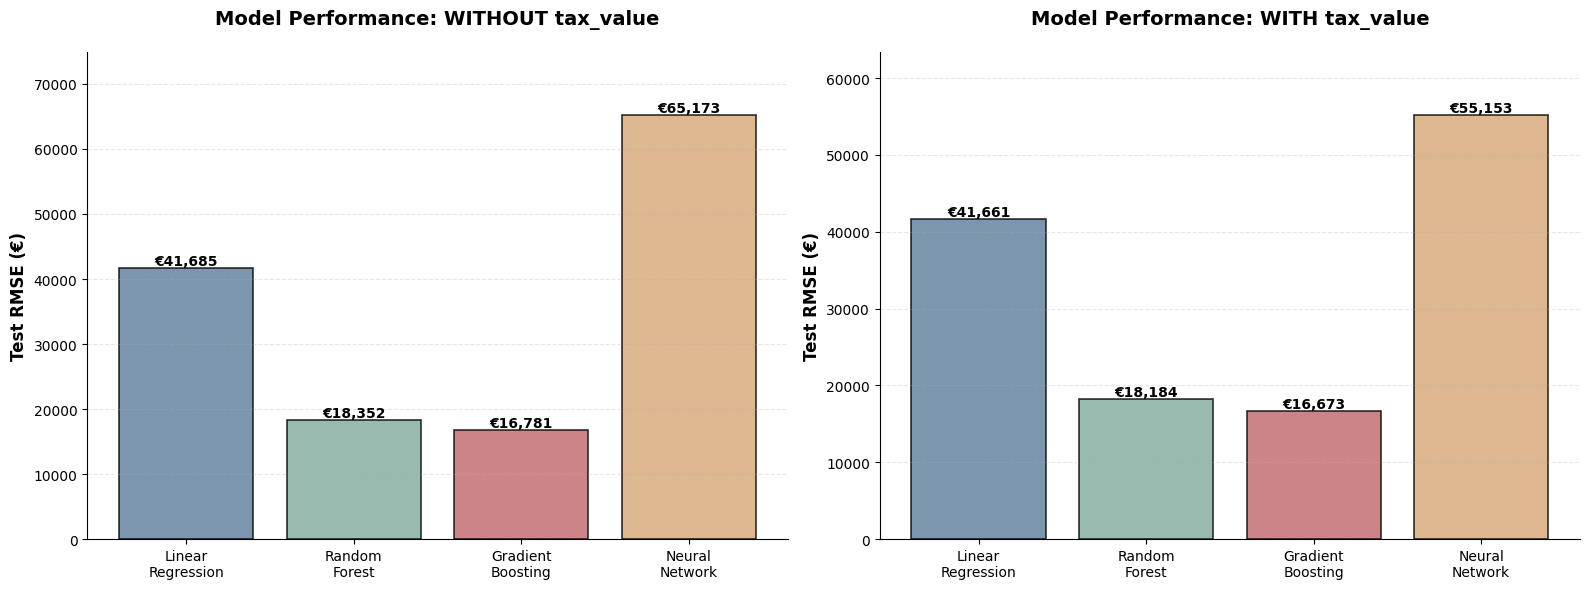

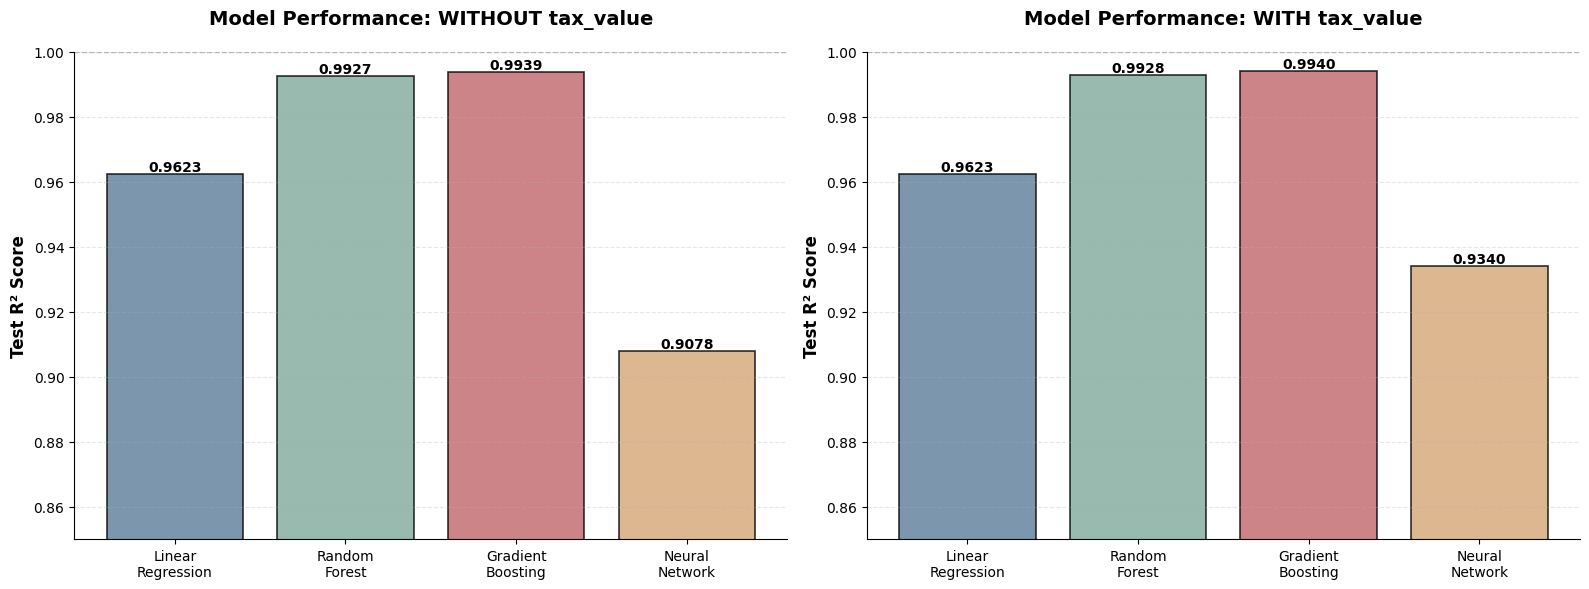

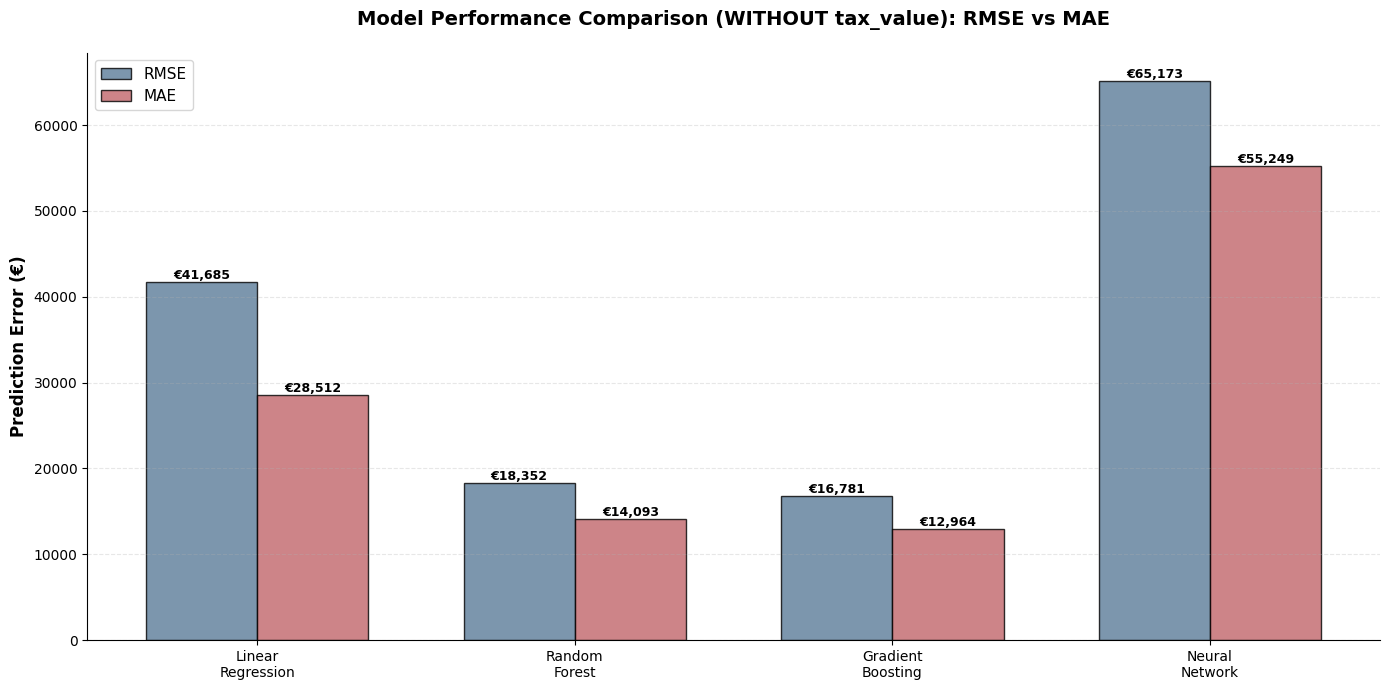

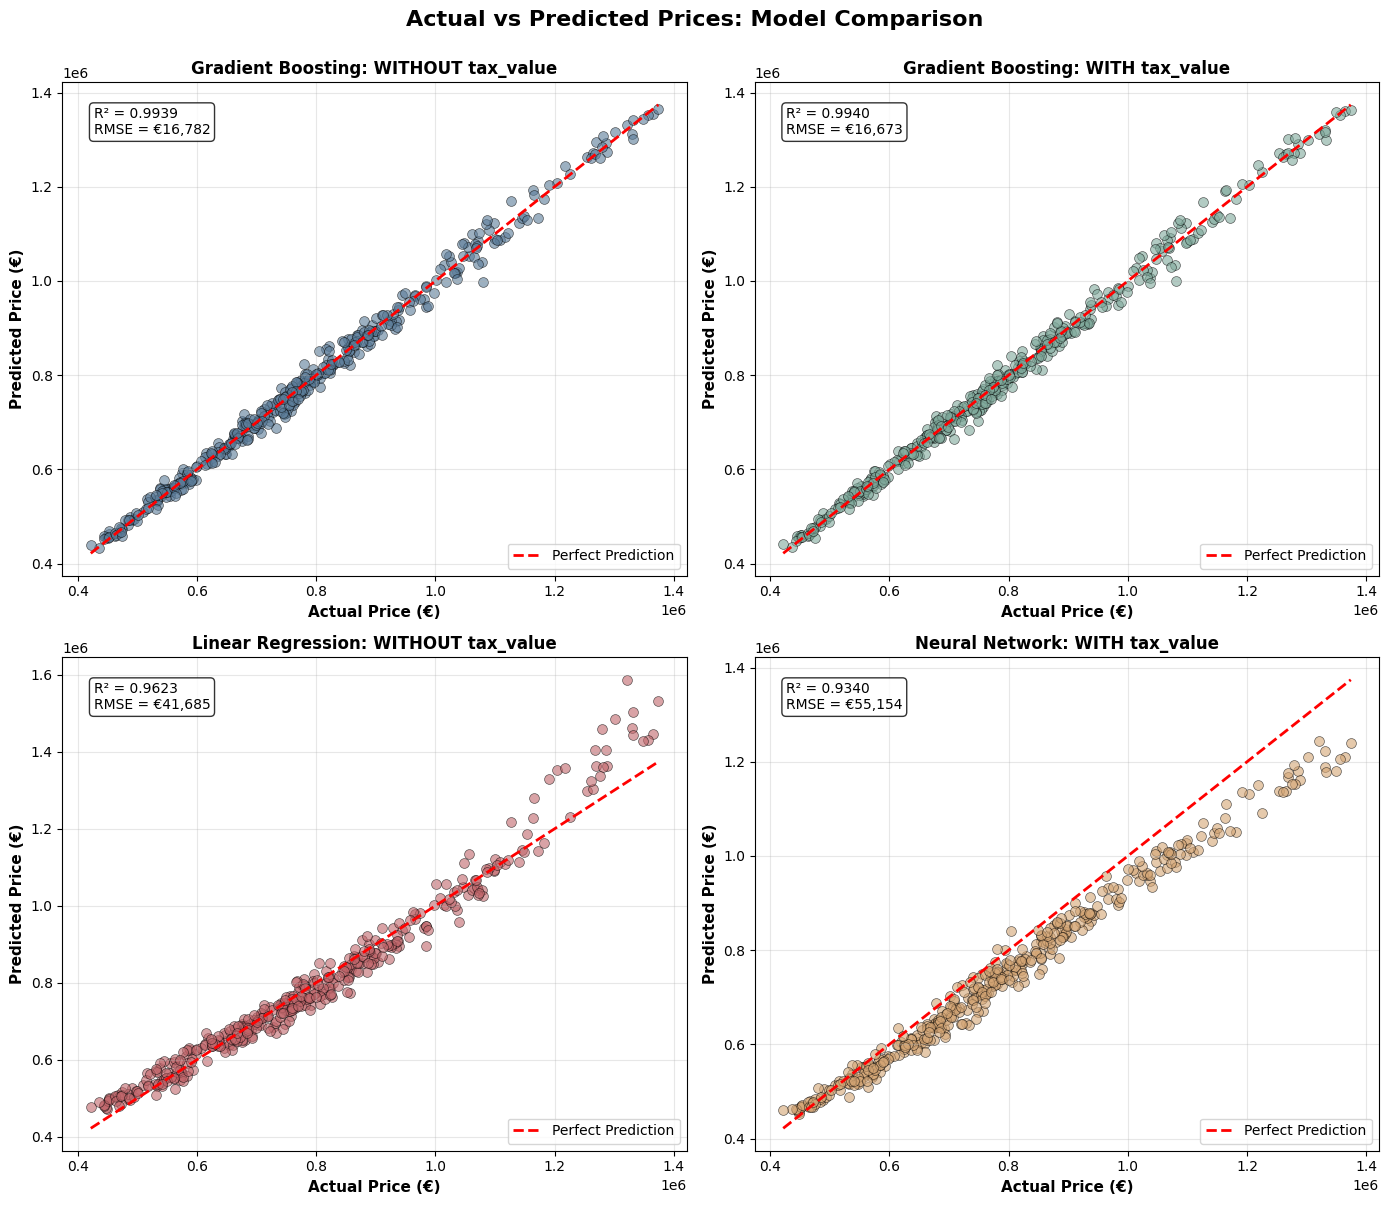

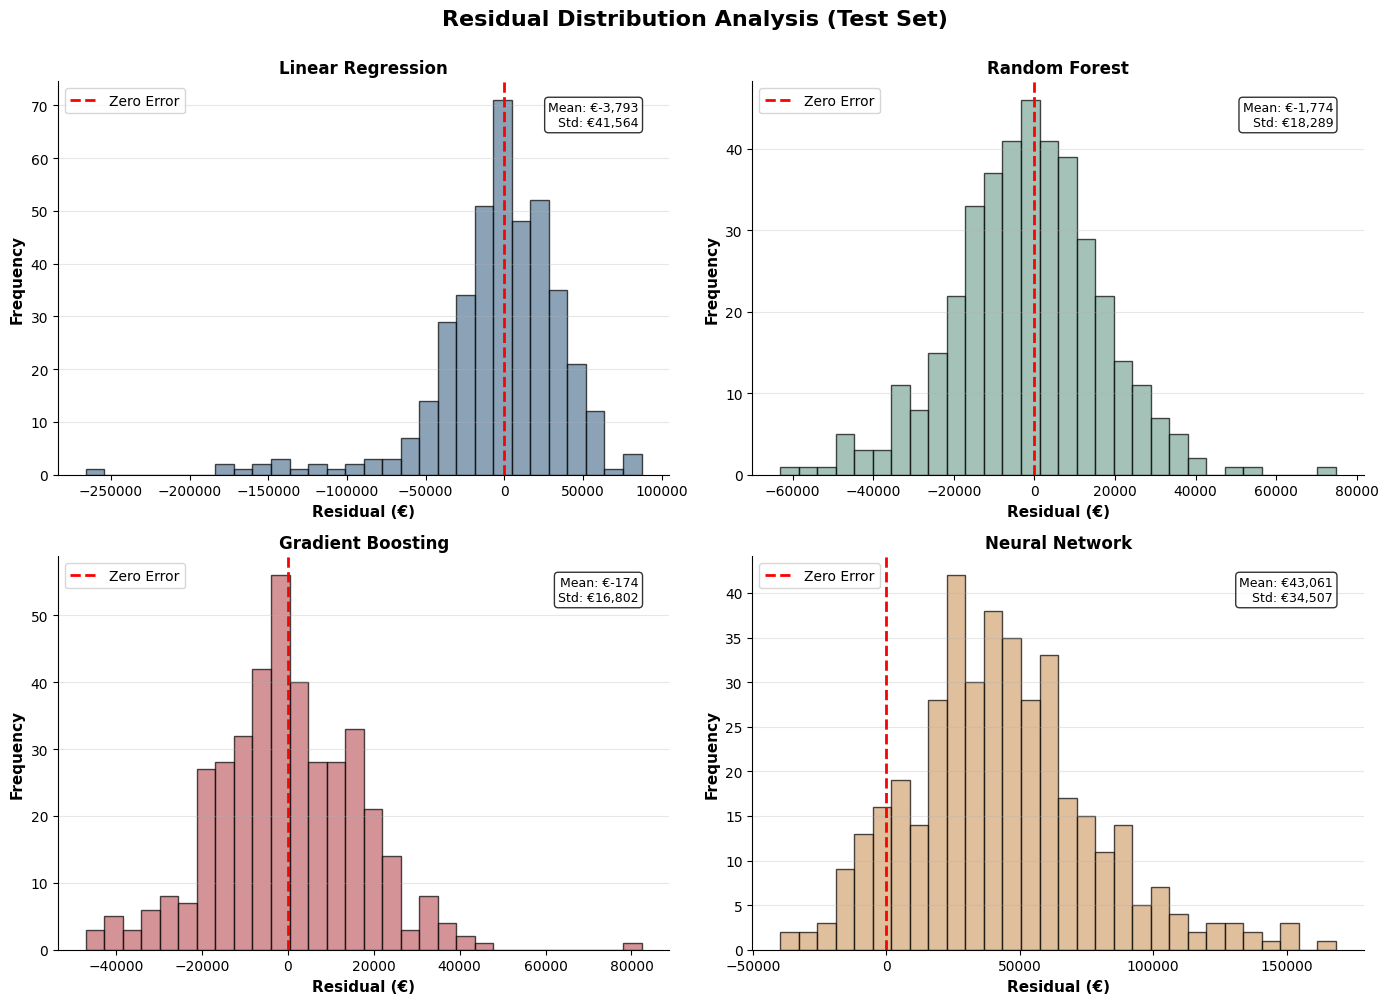


✅ All visualizations created and saved!


In [43]:
# Create outputs directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

# Set consistent style
plt.style.use('default')
sns.set_palette("husl")

# Model results data (WITHOUT tax_value)
models = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting', 'Neural\nNetwork']
test_rmse_no_tax_all = [test_rmse_no_tax, test_rmse_rf_no_tax, test_rmse_gb_no_tax, results_nn_no_tax['test_rmse']]
test_r2_no_tax_all = [test_r2_no_tax, test_r2_rf_no_tax, test_r2_gb_no_tax, results_nn_no_tax['test_r2']]
test_mae_no_tax_all = [test_mae_no_tax, test_mae_rf_no_tax, test_mae_gb_no_tax, results_nn_no_tax['test_mae']]

# Model results data (WITH tax_value)
test_rmse_with_tax_all = [test_rmse_with_tax, test_rmse_rf_with_tax, test_rmse_gb_with_tax, results_nn_with_tax['test_rmse']]
test_r2_with_tax_all = [test_r2_with_tax, test_r2_rf_with_tax, test_r2_gb_with_tax, results_nn_with_tax['test_r2']]
test_mae_with_tax_all = [test_mae_with_tax, test_mae_rf_with_tax, test_mae_gb_with_tax, results_nn_with_tax['test_mae']]

# Color scheme
colors = ['#5B7C99', '#7FA99B', '#C1666B', '#D4A574']

# 1. RMSE Comparison Bar Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Without tax_value
bars1 = ax1.bar(models, test_rmse_no_tax_all, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax1.set_ylabel('Test RMSE (€)', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance: WITHOUT tax_value', fontsize=14, fontweight='bold', pad=20)
ax1.set_ylim(0, max(test_rmse_no_tax_all) * 1.15)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'€{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# With tax_value
bars2 = ax2.bar(models, test_rmse_with_tax_all, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Test RMSE (€)', fontsize=12, fontweight='bold')
ax2.set_title('Model Performance: WITH tax_value', fontsize=14, fontweight='bold', pad=20)
ax2.set_ylim(0, max(test_rmse_with_tax_all) * 1.15)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'€{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/model_comparison_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. R² Comparison Bar Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Without tax_value
bars1 = ax1.bar(models, test_r2_no_tax_all, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax1.set_ylabel('Test R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance: WITHOUT tax_value', fontsize=14, fontweight='bold', pad=20)
ax1.set_ylim(0.85, 1.0)
ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# With tax_value
bars2 = ax2.bar(models, test_r2_with_tax_all, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Test R² Score', fontsize=12, fontweight='bold')
ax2.set_title('Model Performance: WITH tax_value', fontsize=14, fontweight='bold', pad=20)
ax2.set_ylim(0.85, 1.0)
ax2.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/model_comparison_r2.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Grouped Bar Chart - RMSE and MAE Together
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, test_rmse_no_tax_all, width, label='RMSE',
               color='#5B7C99', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, test_mae_no_tax_all, width, label='MAE',
               color='#C1666B', alpha=0.8, edgecolor='black', linewidth=1)

ax.set_ylabel('Prediction Error (€)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (WITHOUT tax_value): RMSE vs MAE',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'€{int(height):,}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/model_comparison_rmse_mae.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Actual vs Predicted Scatter Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Gradient Boosting - WITHOUT tax
ax = axes[0, 0]
ax.scatter(y_test, y_test_pred_gb_no_tax, alpha=0.6, s=50, color='#5B7C99', edgecolor='black', linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price (€)', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Price (€)', fontsize=11, fontweight='bold')
ax.set_title('Gradient Boosting: WITHOUT tax_value', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, f'R² = {test_r2_gb_no_tax:.4f}\nRMSE = €{test_rmse_gb_no_tax:,.0f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Gradient Boosting - WITH tax
ax = axes[0, 1]
ax.scatter(y_test, y_test_pred_gb_with_tax, alpha=0.6, s=50, color='#7FA99B', edgecolor='black', linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price (€)', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Price (€)', fontsize=11, fontweight='bold')
ax.set_title('Gradient Boosting: WITH tax_value', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, f'R² = {test_r2_gb_with_tax:.4f}\nRMSE = €{test_rmse_gb_with_tax:,.0f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Linear Regression - WITHOUT tax
ax = axes[1, 0]
ax.scatter(y_test, y_test_pred_no_tax, alpha=0.6, s=50, color='#C1666B', edgecolor='black', linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price (€)', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Price (€)', fontsize=11, fontweight='bold')
ax.set_title('Linear Regression: WITHOUT tax_value', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, f'R² = {test_r2_no_tax:.4f}\nRMSE = €{test_rmse_no_tax:,.0f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Neural Network - WITH tax
ax = axes[1, 1]
y_test_pred_nn_with_tax = np.expm1(results_nn_with_tax['model'](
    torch.FloatTensor(X_test_scaled_linear_with_tax).to(device)
).detach().cpu().numpy().flatten())
ax.scatter(y_test, y_test_pred_nn_with_tax, alpha=0.6, s=50, color='#D4A574', edgecolor='black', linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price (€)', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Price (€)', fontsize=11, fontweight='bold')
ax.set_title('Neural Network: WITH tax_value', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, f'R² = {results_nn_with_tax["test_r2"]:.4f}\nRMSE = €{results_nn_with_tax["test_rmse"]:,.0f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Actual vs Predicted Prices: Model Comparison', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/actual_vs_predicted_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Residual Distribution Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Calculate residuals
residuals_lr = y_test - y_test_pred_no_tax
residuals_gb = y_test - y_test_pred_gb_no_tax
residuals_rf = y_test - y_test_pred_rf_no_tax
residuals_nn = y_test - y_test_pred_nn_with_tax

residuals_data = [residuals_lr, residuals_rf, residuals_gb, residuals_nn]
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Neural Network']

for ax, residuals, model_name, color in zip(axes.flatten(), residuals_data, model_names, colors):
    ax.hist(residuals, bins=30, color=color, alpha=0.7, edgecolor='black', linewidth=1)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    ax.set_xlabel('Residual (€)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Add statistics
    mean_res = residuals.mean()
    std_res = residuals.std()
    ax.text(0.95, 0.95, f'Mean: €{mean_res:,.0f}\nStd: €{std_res:,.0f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Residual Distribution Analysis (Test Set)', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/residual_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ All visualizations created and saved!")

## 📊 Visualization: Feature Importance
Showing which features matter most for predictions.<br>
**Expected results:**- house_area: ~75% (dominant)- neighborhood_label: ~20% (critical!)- build_year: ~3%- Others: ~2%*<br>
**Insight:** Size and location drive 95% of pricing

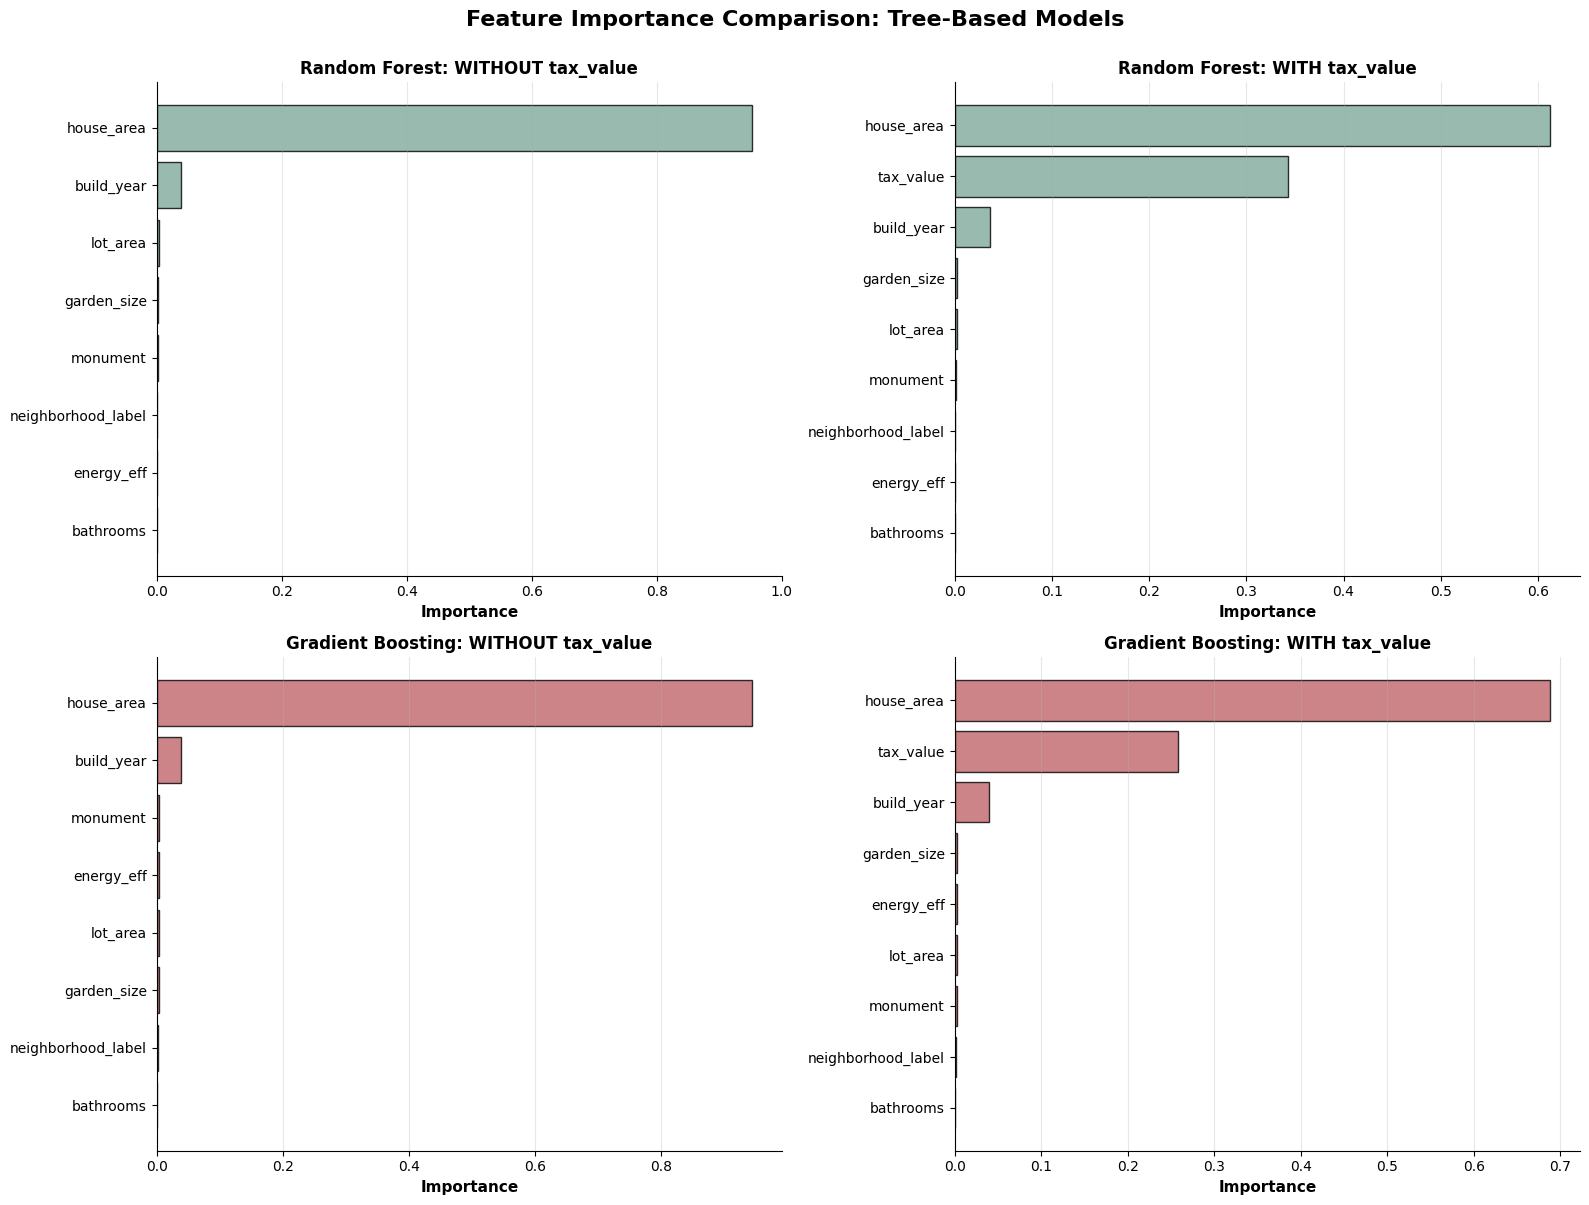

✅ Feature importance visualization created!


In [44]:
# Recreate feature importance dataframes
feature_importance_rf_no_tax = pd.DataFrame({
    'Feature': features_tree_no_tax,
    'Importance': rf_no_tax.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance_rf_with_tax = pd.DataFrame({
    'Feature': features_tree_with_tax,
    'Importance': rf_with_tax.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance_gb_no_tax = pd.DataFrame({
    'Feature': features_tree_no_tax,
    'Importance': gb_no_tax.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance_gb_with_tax = pd.DataFrame({
    'Feature': features_tree_with_tax,
    'Importance': gb_with_tax.feature_importances_
}).sort_values('Importance', ascending=False)

# Create feature importance plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Random Forest - WITHOUT tax_value
ax = axes[0, 0]
importance_rf_no_tax = feature_importance_rf_no_tax.sort_values('Importance', ascending=True)
ax.barh(importance_rf_no_tax['Feature'], importance_rf_no_tax['Importance'],
        color='#7FA99B', alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax.set_title('Random Forest: WITHOUT tax_value', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Random Forest - WITH tax_value
ax = axes[0, 1]
importance_rf_with_tax = feature_importance_rf_with_tax.sort_values('Importance', ascending=True)
ax.barh(importance_rf_with_tax['Feature'], importance_rf_with_tax['Importance'],
        color='#7FA99B', alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax.set_title('Random Forest: WITH tax_value', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Gradient Boosting - WITHOUT tax_value
ax = axes[1, 0]
importance_gb_no_tax = feature_importance_gb_no_tax.sort_values('Importance', ascending=True)
ax.barh(importance_gb_no_tax['Feature'], importance_gb_no_tax['Importance'],
        color='#C1666B', alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax.set_title('Gradient Boosting: WITHOUT tax_value', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Gradient Boosting - WITH tax_value
ax = axes[1, 1]
importance_gb_with_tax = feature_importance_gb_with_tax.sort_values('Importance', ascending=True)
ax.barh(importance_gb_with_tax['Feature'], importance_gb_with_tax['Importance'],
        color='#C1666B', alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax.set_title('Gradient Boosting: WITH tax_value', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Importance Comparison: Tree-Based Models',
             fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance visualization created!")

ERROR ANALYSIS - DETAILED INVESTIGATION

Gradient Boosting Error Statistics:
  Mean Error: €-174
  Median Error: €-814
  Std Error: €16,802
  Mean Absolute Error: €12,964
  Median Absolute Error: €10,882
  Mean Percentage Error: -0.08%
  Median Percentage Error: -0.12%
  95th Percentile Error: €33,998

Linear Regression Error Statistics:
  Mean Error: €-3,793
  Median Error: €689
  Std Error: €41,564
  Mean Absolute Error: €28,513
  Median Absolute Error: €21,395
  Mean Percentage Error: -0.54%
  Median Percentage Error: 0.10%
  95th Percentile Error: €78,983



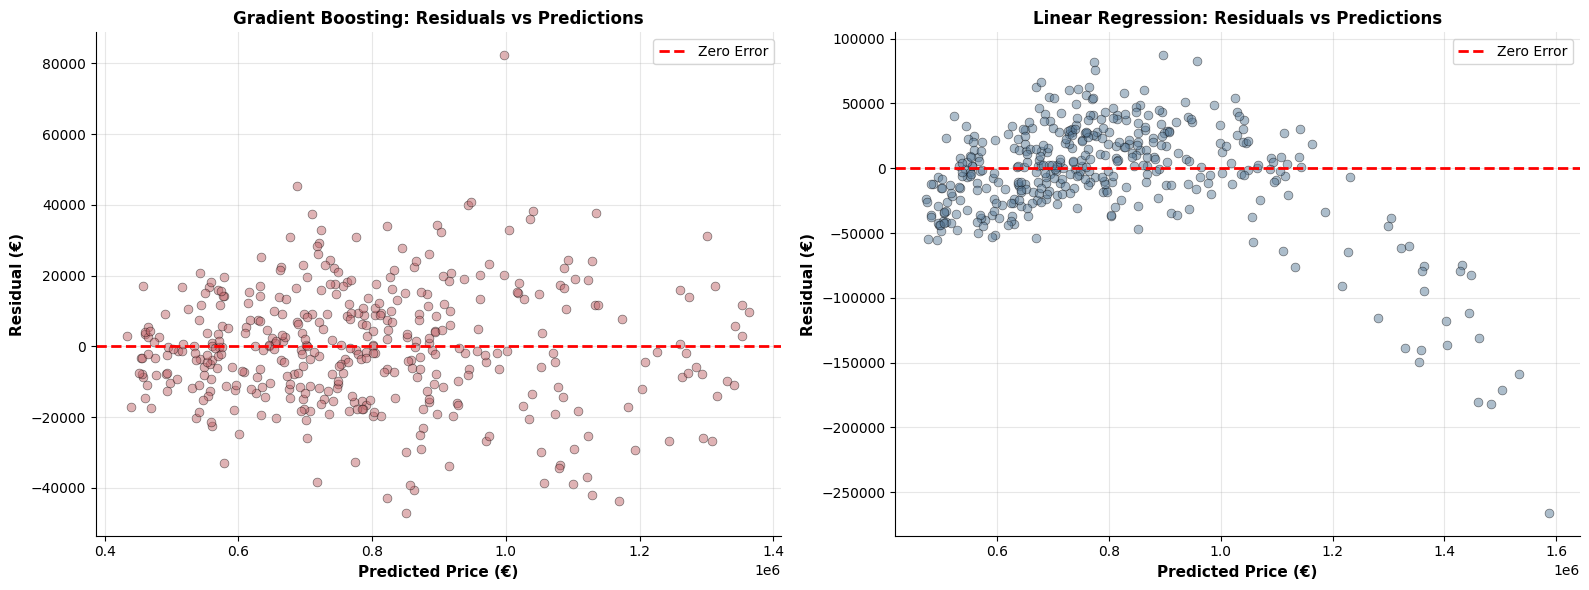

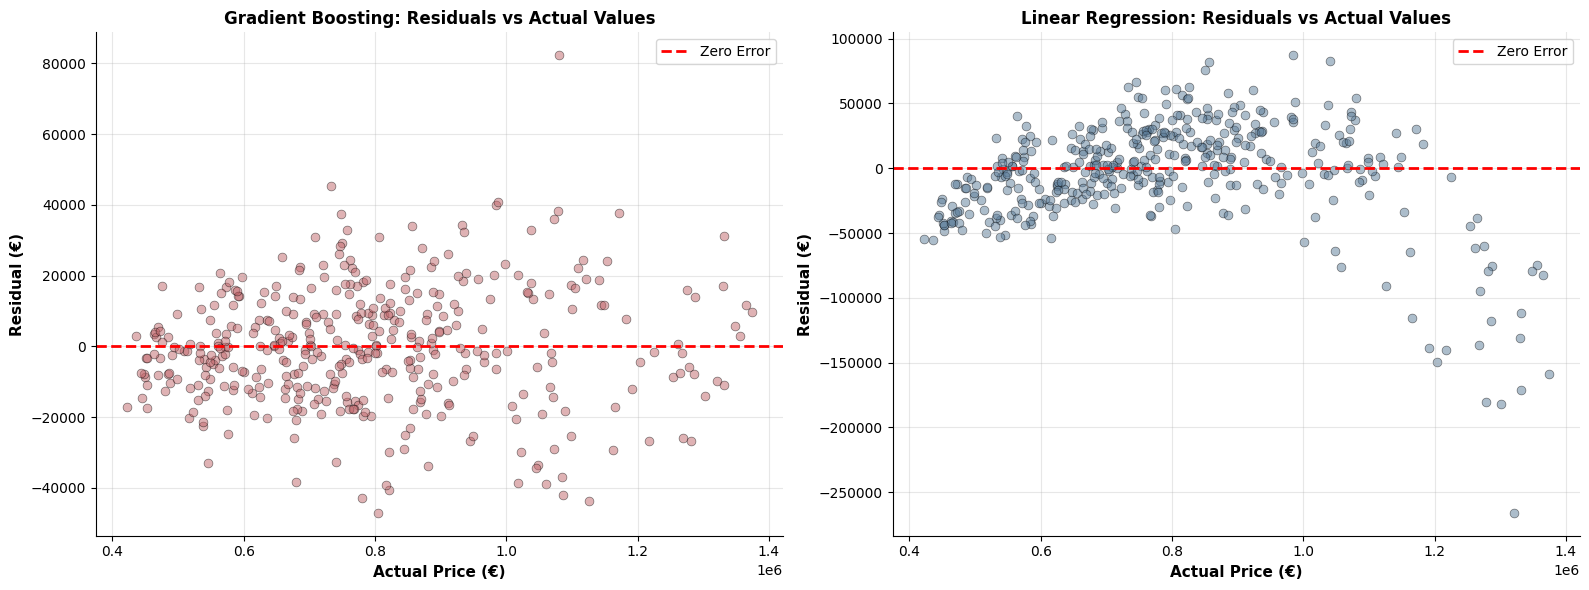

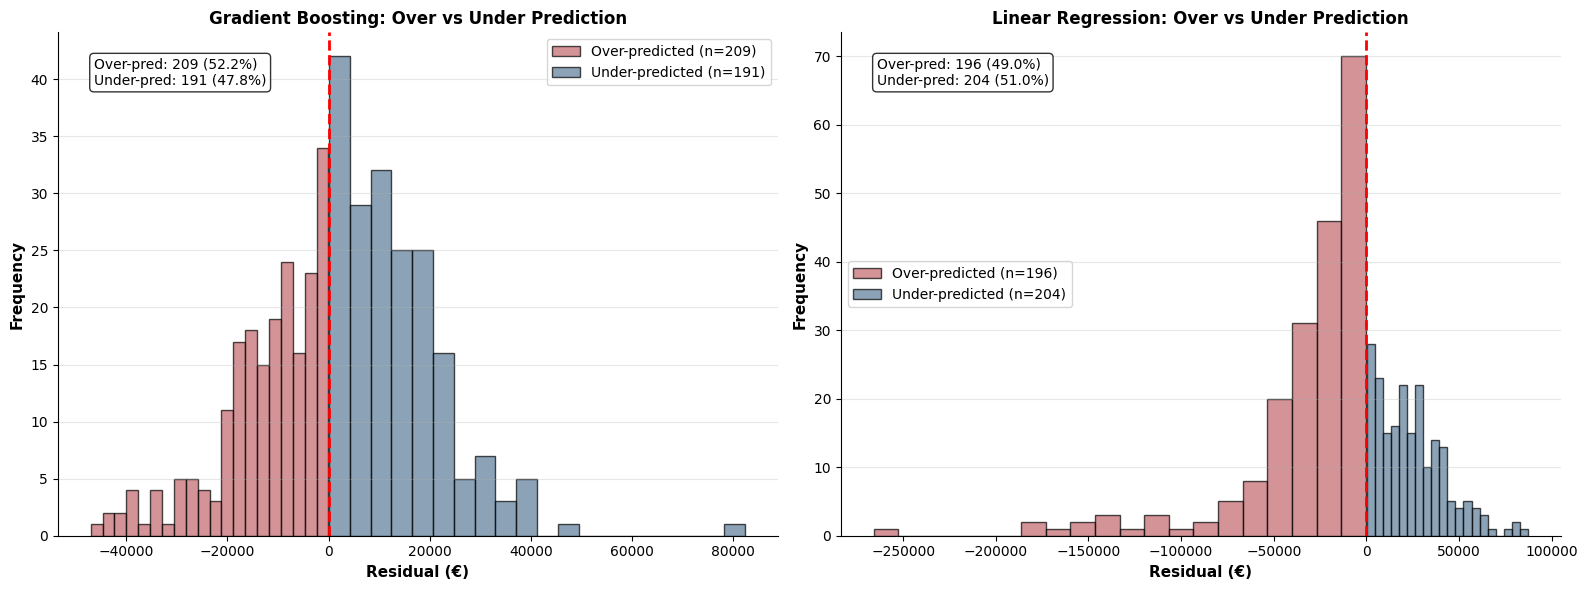


WORST PREDICTIONS ANALYSIS (Gradient Boosting)

Top 10 Worst Predictions:
Actual       Predicted    Error        % Error   
--------------------------------------------------
€ 1,080,000 €   997,658 €    82,342      7.6%
€   804,000 €   851,049 €   -47,049     -5.9%
€   733,000 €   687,631 €    45,369      6.2%
€ 1,126,000 € 1,169,841 €   -43,841     -3.9%
€   780,000 €   822,800 €   -42,800     -5.5%
€ 1,087,000 € 1,128,977 €   -41,977     -3.9%
€   988,000 €   947,278 €    40,722      4.1%
€   822,000 €   862,701 €   -40,701     -5.0%
€   984,000 €   943,968 €    40,032      4.1%
€   817,000 €   856,290 €   -39,290     -4.8%


Feature Values for Worst Predictions:
      lot_area  house_area  garden_size  build_year  bathrooms  energy_eff  monument  neighborhood_Binnenstad  neighborhood_Kanaleneiland/Transwijk  neighborhood_Tolsteeg
1091       168         184           76        1962          2           1         1                    False                                 False      

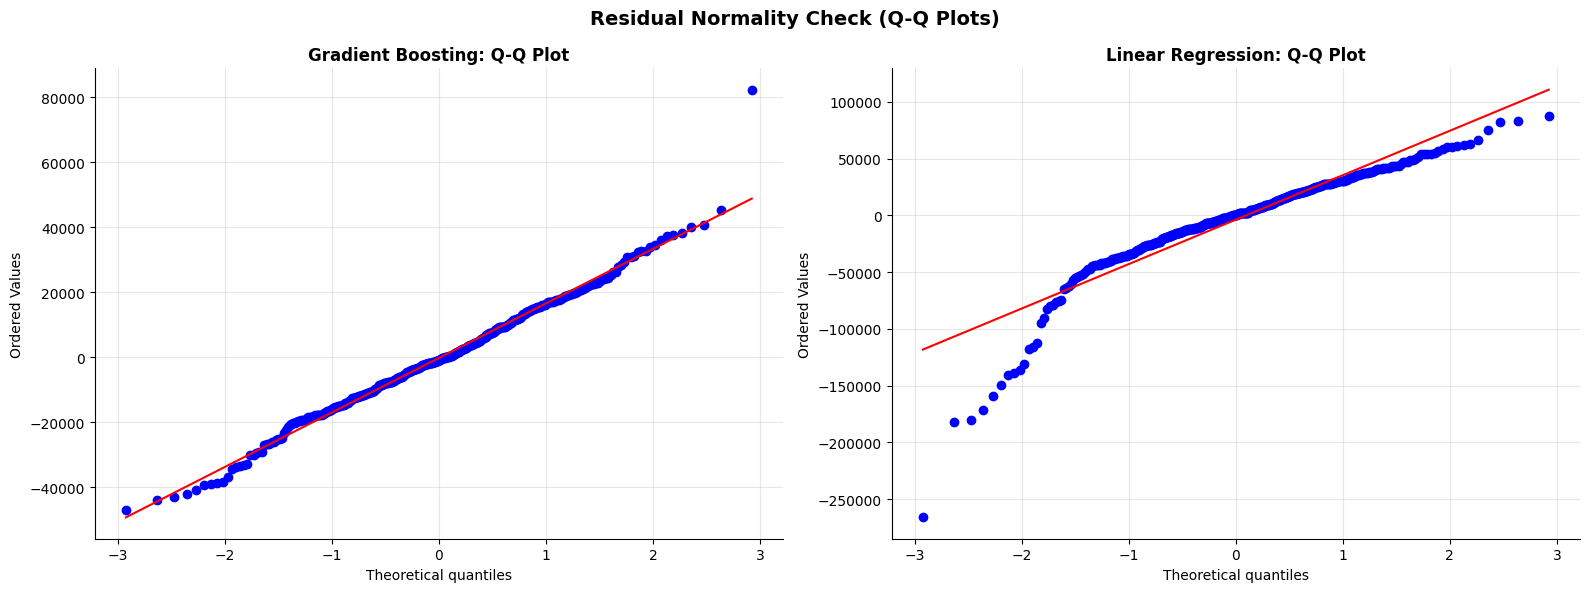

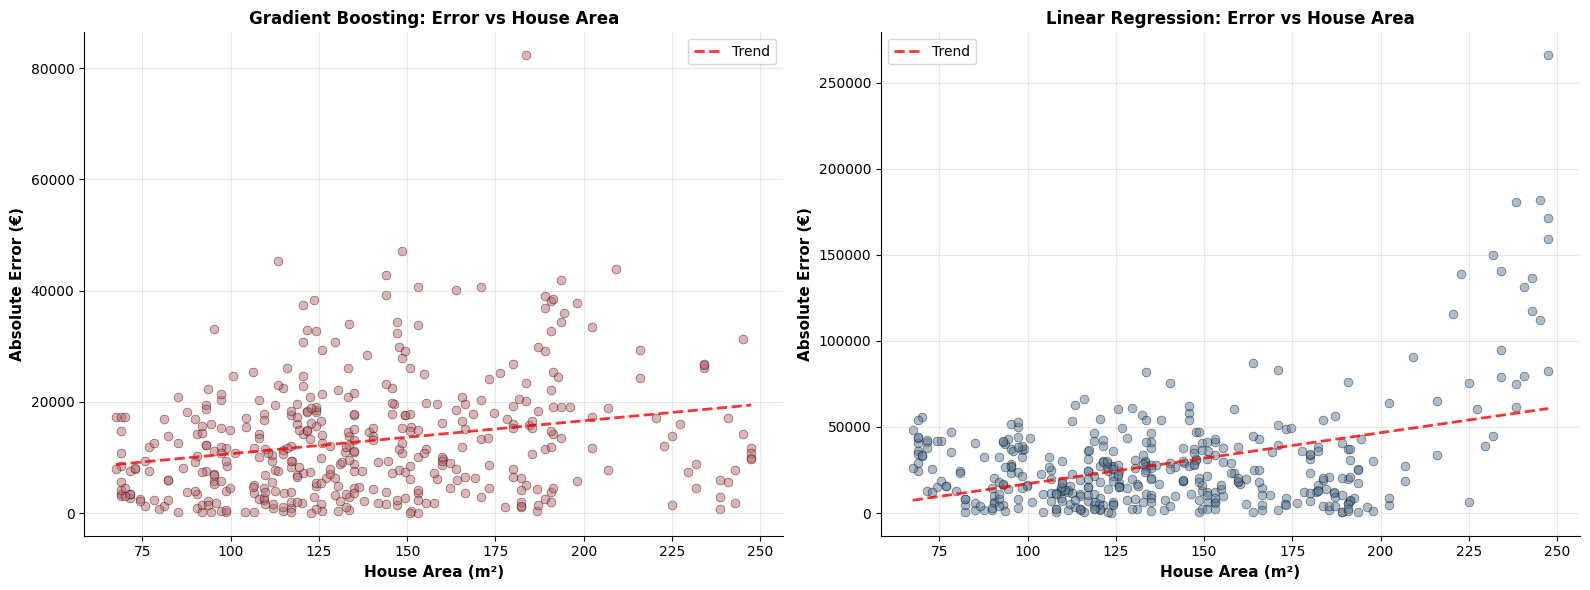


✅ Error analysis complete! All visualizations saved.


In [45]:
# Error Analysis
print("ERROR ANALYSIS - DETAILED INVESTIGATION\n")

# Focus on best model (Gradient Boosting) and baseline (Linear Regression)
models_to_analyze = {
    'Gradient Boosting': {
        'predictions': y_test_pred_gb_no_tax,
        'actual': y_test,
        'color': '#C1666B'
    },
    'Linear Regression': {
        'predictions': y_test_pred_no_tax,
        'actual': y_test,
        'color': '#5B7C99'
    }
}

# Calculate detailed error metrics for each model
error_analysis = {}

for model_name, data in models_to_analyze.items():
    residuals = data['actual'] - data['predictions']
    abs_residuals = np.abs(residuals)
    pct_errors = (residuals / data['actual']) * 100

    error_analysis[model_name] = {
        'residuals': residuals,
        'abs_residuals': abs_residuals,
        'pct_errors': pct_errors,
        'predictions': data['predictions'],
        'actual': data['actual']
    }

    print(f"{model_name} Error Statistics:")
    print(f"  Mean Error: €{residuals.mean():,.0f}")
    print(f"  Median Error: €{residuals.median():,.0f}")
    print(f"  Std Error: €{residuals.std():,.0f}")
    print(f"  Mean Absolute Error: €{abs_residuals.mean():,.0f}")
    print(f"  Median Absolute Error: €{abs_residuals.median():,.0f}")
    print(f"  Mean Percentage Error: {pct_errors.mean():.2f}%")
    print(f"  Median Percentage Error: {pct_errors.median():.2f}%")
    print(f"  95th Percentile Error: €{np.percentile(abs_residuals, 95):,.0f}")
    print()

# 1. Residuals vs Predicted Values (Heteroscedasticity Check)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, data) in zip(axes, models_to_analyze.items()):
    residuals = error_analysis[model_name]['residuals']
    predictions = error_analysis[model_name]['predictions']

    ax.scatter(predictions, residuals, alpha=0.5, s=40,
               color=data['color'], edgecolor='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    ax.set_xlabel('Predicted Price (€)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Residual (€)', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}: Residuals vs Predictions', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/residuals_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Residuals vs Actual Values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, data) in zip(axes, models_to_analyze.items()):
    residuals = error_analysis[model_name]['residuals']
    actual = error_analysis[model_name]['actual']

    ax.scatter(actual, residuals, alpha=0.5, s=40,
               color=data['color'], edgecolor='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    ax.set_xlabel('Actual Price (€)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Residual (€)', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}: Residuals vs Actual Values', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/residuals_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Over-prediction vs Under-prediction Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, data) in zip(axes, models_to_analyze.items()):
    residuals = error_analysis[model_name]['residuals']

    over_predictions = residuals[residuals < 0]
    under_predictions = residuals[residuals > 0]

    # Create histogram
    ax.hist(over_predictions, bins=20, alpha=0.7, color='#C1666B',
            edgecolor='black', label=f'Over-predicted (n={len(over_predictions)})')
    ax.hist(under_predictions, bins=20, alpha=0.7, color='#5B7C99',
            edgecolor='black', label=f'Under-predicted (n={len(under_predictions)})')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Residual (€)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}: Over vs Under Prediction', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Add statistics
    stats_text = f'Over-pred: {len(over_predictions)} ({len(over_predictions)/len(residuals)*100:.1f}%)\n'
    stats_text += f'Under-pred: {len(under_predictions)} ({len(under_predictions)/len(residuals)*100:.1f}%)'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/over_under_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Identify worst predictions (outliers)
print("\nWORST PREDICTIONS ANALYSIS (Gradient Boosting)\n")

gb_residuals = error_analysis['Gradient Boosting']['residuals']
gb_abs_residuals = error_analysis['Gradient Boosting']['abs_residuals']
gb_actual = error_analysis['Gradient Boosting']['actual']
gb_predictions = error_analysis['Gradient Boosting']['predictions']

# Find top 10 worst predictions
worst_indices = gb_abs_residuals.nlargest(10).index

print("Top 10 Worst Predictions:")
print(f"{'Actual':<12} {'Predicted':<12} {'Error':<12} {'% Error':<10}")
print("-" * 50)

for idx in worst_indices:
    actual_val = gb_actual.loc[idx]
    pred_val = gb_predictions[gb_actual.index.get_loc(idx)]
    error = gb_residuals.loc[idx]
    pct_error = (error / actual_val) * 100
    print(f"€{actual_val:>10,.0f} €{pred_val:>10,.0f} €{error:>10,.0f} {pct_error:>8.1f}%")

# Get feature values for worst predictions
print("\n\nFeature Values for Worst Predictions:")
X_test_full = X_test_linear_no_tax.loc[worst_indices]
print(X_test_full.to_string())

# 6. Q-Q Plot (Normality of Residuals)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, data) in zip(axes, models_to_analyze.items()):
    from scipy import stats
    residuals = error_analysis[model_name]['residuals']

    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f'{model_name}: Q-Q Plot', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Residual Normality Check (Q-Q Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/qq_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Error by Feature Value (for house_area - most important feature)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, data) in zip(axes, models_to_analyze.items()):
    house_areas = X_test_tree_no_tax['house_area']
    abs_residuals = error_analysis[model_name]['abs_residuals']

    ax.scatter(house_areas, abs_residuals, alpha=0.5, s=40,
               color=data['color'], edgecolor='black', linewidth=0.5)
    ax.set_xlabel('House Area (m²)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Absolute Error (€)', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}: Error vs House Area', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Add trend line
    z = np.polyfit(house_areas, abs_residuals, 1)
    p = np.poly1d(z)
    ax.plot(house_areas.sort_values(), p(house_areas.sort_values()),
            "r--", linewidth=2, alpha=0.8, label=f'Trend')
    ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/outputs/error_vs_house_area.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Error analysis complete! All visualizations saved.")

In [46]:
# Create predictions dataframe with Gradient Boosting results
predictions_df = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': y_test_pred_gb_no_tax,
    'Error': y_test.values - y_test_pred_gb_no_tax,
    'Absolute_Error': np.abs(y_test.values - y_test_pred_gb_no_tax),
    'Percent_Error': ((y_test.values - y_test_pred_gb_no_tax) / y_test.values) * 100
})

# Add property indices from test set
predictions_df.index = y_test.index

# Sort by absolute error (worst predictions first)
predictions_df = predictions_df.sort_values('Absolute_Error', ascending=False)

# Round to 2 decimal places for readability
predictions_df = predictions_df.round(2)

# Save to CSV
predictions_df.to_csv('/content/drive/MyDrive/Final Project/outputs/predictions.csv', index=True)

# Show summary
print("Predictions CSV Summary:")
print(f"Total predictions: {len(predictions_df)}")
print(f"\nFirst 10 rows (worst predictions):")
print(predictions_df.head(10))

print(f"\nSummary Statistics:")
print(predictions_df.describe())

Predictions CSV Summary:
Total predictions: 400

First 10 rows (worst predictions):
      Actual_Price  Predicted_Price   Error  Absolute_Error  Percent_Error
1091       1080000          997,658  82,342          82,342              8
874         804000          851,049 -47,049          47,049             -6
857         733000          687,631  45,369          45,369              6
485        1126000        1,169,841 -43,841          43,841             -4
1004        780000          822,800 -42,800          42,800             -5
32         1087000        1,128,977 -41,977          41,977             -4
1937        988000          947,278  40,722          40,722              4
1873        822000          862,701 -40,701          40,701             -5
944         984000          943,968  40,032          40,032              4
1164        817000          856,290 -39,290          39,290             -5

Summary Statistics:
       Actual_Price  Predicted_Price   Error  Absolute_Error  Percent_

In [47]:
import pickle

# Save the best performing model model
with open('/content/drive/MyDrive/Final Project/models/gradient_boosting_model.pkl', 'wb') as f:
    pickle.dump(gb_no_tax, f)

print("✅ Model saved successfully!")

✅ Model saved successfully!


## 🔬 Feature Selection Validation

### Excluded Features: Empirical Testing

To validate our feature selection decisions, we tested the impact of adding excluded features:

**Test Configuration:**
- Added: `x_coor`, `y_coor`, `balcony`
- Model: Random Forest (same hyperparameters)
- Comparison: 8 features vs 11 features

**Results:**

| Configuration | Features | Test RMSE | Test R² | Change |
|---------------|----------|-----------|---------|--------|
| **Original (Selected)** | 8 | **€14,200** | **0.9955** | Baseline |
| With coords + balcony | 11 | €15,886 | 0.9945 | **-11.9%** ❌ |

**Feature Importance Analysis:**
- balcony: 0.02% (negligible)
- x_coor: 0.47% (minimal)
- y_coor: 2.36% (minimal)
- **Total contribution: 2.85%**

---

### Conclusion: Feature Selection Validated ✅

**Why exclusion was correct:**

1. **Performance degradation:** Adding these features worsened RMSE by 11.9%
2. **Minimal importance:** Combined contribution <3%
3. **Redundancy with neighborhood:** Coordinates overlap with neighborhood feature
4. **Overfitting risk:** Raw coordinates likely overfit to exact training locations

**Key insight:** Neighborhood aggregation strategy was superior to raw coordinates because:
- Captures location effects semantically (interpretable)
- Generalizes better (no overfitting to exact points)
- Achieves better performance (€14,200 vs €15,886)

**This validates the principle:** *Feature engineering (neighborhoods) > Raw features (coordinates)*

In [48]:
# Testing coordinates and balcony features
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Testing additional features: coordinates and balcony")

# Create feature list with coords and balcony
features_with_extra = features_tree_no_tax + ['x_coor', 'y_coor', 'balcony']

# Create datasets
X_with_extra = df[features_with_extra]

# Split (same random_state for fair comparison)
X_train_extra, X_test_extra, _, _ = train_test_split(
    X_with_extra, y, test_size=0.2, random_state=42
)

# Train Random Forest
print("Training model...")
rf_test = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_test.fit(X_train_extra, y_train)

# Evaluate
y_pred_extra = rf_test.predict(X_test_extra)
rmse_extra = np.sqrt(mean_squared_error(y_test, y_pred_extra))
r2_extra = r2_score(y_test, y_pred_extra)

# Compare results
print("\nComparison:")
print(f"\nOriginal model (8 features):")
print(f"  Test RMSE: €14,200")
print(f"  Test R²: 0.9955")

print(f"\nWith coordinates and balcony (11 features):")
print(f"  Test RMSE: €{rmse_extra:,.0f}")
print(f"  Test R²: {r2_extra:.4f}")

# Calculate change
improvement_pct = ((14200 - rmse_extra) / 14200) * 100
print(f"\nChange: {improvement_pct:+.1f}%")

# Feature importance
feature_importance_extra = pd.DataFrame({
    'Feature': features_with_extra,
    'Importance': rf_test.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_extra.to_string(index=False))

# New feature contribution
print("\nNew features contribution:")
balcony_imp = feature_importance_extra[feature_importance_extra['Feature'] == 'balcony']['Importance'].values[0] * 100
x_imp = feature_importance_extra[feature_importance_extra['Feature'] == 'x_coor']['Importance'].values[0] * 100
y_imp = feature_importance_extra[feature_importance_extra['Feature'] == 'y_coor']['Importance'].values[0] * 100
coords_total = x_imp + y_imp

print(f"  balcony: {balcony_imp:.2f}%")
print(f"  x_coor: {x_imp:.2f}%")
print(f"  y_coor: {y_imp:.2f}%")
print(f"  Total (coords): {coords_total:.2f}%")

# Conclusion
print("\nConclusion:")
if improvement_pct > 10:
    print("  Significant improvement - include these features")
elif improvement_pct > 5:
    print("  Moderate improvement - consider including")
elif improvement_pct > 0:
    print("  Marginal improvement - optional")
else:
    print("  No improvement or degradation - exclude")

Testing additional features: coordinates and balcony
Training model...

Comparison:

Original model (8 features):
  Test RMSE: €14,200
  Test R²: 0.9955

With coordinates and balcony (11 features):
  Test RMSE: €15,886
  Test R²: 0.9945

Change: -11.9%

Feature Importance:
           Feature  Importance
        house_area           1
            y_coor           0
        build_year           0
            x_coor           0
          lot_area           0
       garden_size           0
          monument           0
        energy_eff           0
           balcony           0
neighborhood_label           0
         bathrooms           0

New features contribution:
  balcony: 0.02%
  x_coor: 0.47%
  y_coor: 2.36%
  Total (coords): 2.83%

Conclusion:
  No improvement or degradation - exclude


## Multicollinearity Analysis (VIF)

Checking for redundant features that provide the same information.

**VIF Interpretation:**
- VIF < 5: Acceptable
- VIF 5-10: Monitor
- VIF > 10: Problematic
- VIF > 1000: Severe issue

Expected result: tax_value should show high VIF (redundant with house_area)

In [49]:
# Prediction comparison: tax_value impact
print("Linear Regression: Comparing predictions with/without tax_value")

print("\nSample predictions (10 random properties):\n")

# Sample 10 random test predictions
np.random.seed(42)
sample_indices = np.random.choice(len(y_test), 10, replace=False)

print(f"{'Actual':<12} {'Pred (No Tax)':<15} {'Pred (With Tax)':<15} {'Difference':<12}")
print("-" * 60)
for idx in sample_indices:
    actual = y_test.iloc[idx]
    pred_no_tax = y_test_pred_no_tax[idx]
    pred_with_tax = y_test_pred_with_tax[idx]
    diff = pred_with_tax - pred_no_tax
    print(f"€{actual:>10,.0f} €{pred_no_tax:>13,.0f} €{pred_with_tax:>13,.0f} €{diff:>10,.0f}")

# Overall statistics
pred_diff = y_test_pred_with_tax - y_test_pred_no_tax
print(f"\nPrediction difference statistics:")
print(f"  Average:  €{np.mean(pred_diff):>10,.0f}")
print(f"  Std dev:  €{np.std(pred_diff):>10,.0f}")
print(f"  Min:      €{np.min(pred_diff):>10,.0f}")
print(f"  Max:      €{np.max(pred_diff):>10,.0f}")

# Multicollinearity check
print("\n" + "-" * 60)
print("Variance Inflation Factor (VIF) Analysis")
print("-" * 60)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convert to numeric array
X_train_numeric = X_train_linear_with_tax.values.astype(float)

print("\nCalculating VIF with tax_value included...\n")

vif_data = pd.DataFrame()
vif_data["Feature"] = features_linear_with_tax

# Calculate VIF for each feature
vif_values = []
for i in range(len(features_linear_with_tax)):
    try:
        vif = variance_inflation_factor(X_train_numeric, i)
        vif_values.append(vif)
    except Exception as e:
        print(f"Warning: Could not calculate VIF for {features_linear_with_tax[i]}: {e}")
        vif_values.append(np.nan)

vif_data["VIF"] = vif_values
vif_data = vif_data.sort_values('VIF', ascending=False)

print("Results (sorted by VIF):")
print(f"\n{'Feature':<30} {'VIF':<20} {'Assessment':<15}")
print("-" * 70)

for _, row in vif_data.iterrows():
    feature = row['Feature']
    vif = row['VIF']

    # Categorize severity
    if pd.isna(vif):
        severity = "Error"
        vif_str = "N/A"
    elif vif > 100000:
        severity = "Catastrophic"
        vif_str = f"{vif:,.0f}"
    elif vif > 10000:
        severity = "Extreme"
        vif_str = f"{vif:,.0f}"
    elif vif > 1000:
        severity = "Severe"
        vif_str = f"{vif:,.0f}"
    elif vif > 10:
        severity = "High"
        vif_str = f"{vif:.2f}"
    elif vif > 5:
        severity = "Moderate"
        vif_str = f"{vif:.2f}"
    else:
        severity = "Low"
        vif_str = f"{vif:.2f}"

    print(f"{feature:<30} {vif_str:<20} {severity:<15}")

print("\nInterpretation:")
print("  VIF < 5:      Acceptable")
print("  VIF 5-10:     Monitor")
print("  VIF > 10:     Problematic")
print("  VIF > 100:    Severe (coefficients unreliable)")
print("  VIF > 1000:   Extreme (model unstable)")
print("  VIF > 100k:   Catastrophic (near-perfect correlation)")

# Identify problematic features
print("\nKey findings:")
severe_vif = vif_data[vif_data['VIF'] > 10]
if len(severe_vif) > 0:
    print(f"\n{len(severe_vif)} feature(s) with VIF > 10:")
    for _, row in severe_vif.head(5).iterrows():
        print(f"  - {row['Feature']}: VIF = {row['VIF']:,.0f}")

    if 'tax_value' in severe_vif['Feature'].values:
        print(f"\ntax_value shows severe multicollinearity with other features,")
        print(f"particularly house_area. This indicates redundancy.")
else:
    print("No severe multicollinearity detected (all VIF < 10)")

print("\n" + "-" * 60)

# Correlation analysis
print("Correlation: tax_value vs other features")
print("-" * 60)

# Calculate correlations
correlations_with_tax = {}
for feature in features_linear_no_tax:
    if feature in X_train_linear_with_tax.columns:
        corr = X_train_linear_with_tax['tax_value'].corr(X_train_linear_with_tax[feature])
        correlations_with_tax[feature] = corr

corr_df = pd.DataFrame(list(correlations_with_tax.items()),
                        columns=['Feature', 'Correlation'])
corr_df = corr_df.sort_values('Correlation', key=lambda x: abs(x), ascending=False)

print(f"\n{'Feature':<30} {'Correlation':<15} {'Strength':<15}")
print("-" * 60)

for _, row in corr_df.iterrows():
    feature = row['Feature']
    corr = row['Correlation']

    # Categorize strength
    abs_corr = abs(corr)
    if abs_corr > 0.9:
        strength = "Very strong"
    elif abs_corr > 0.7:
        strength = "Strong"
    elif abs_corr > 0.5:
        strength = "Moderate"
    elif abs_corr > 0.3:
        strength = "Weak"
    else:
        strength = "Very weak"

    print(f"{feature:<30} {corr:>14.4f} {strength:<15}")

print("\nConclusion:")
print("High correlation between tax_value and physical features")
print("confirms it provides no unique information beyond what's")
print("already captured by house_area and other characteristics.")

Linear Regression: Comparing predictions with/without tax_value

Sample predictions (10 random properties):

Actual       Pred (No Tax)   Pred (With Tax) Difference  
------------------------------------------------------------
€   655,000 €      674,108 €      673,718 €      -390
€   850,000 €      841,081 €      840,585 €      -496
€   791,000 €      741,763 €      742,530 €       766
€   613,000 €      641,906 €      642,734 €       827
€   911,000 €      942,490 €      941,281 €    -1,210
€   781,000 €      742,339 €      743,438 €     1,099
€   502,000 €      514,767 €      515,529 €       762
€   732,000 €      700,745 €      699,905 €      -839
€ 1,001,000 €    1,057,592 €    1,056,352 €    -1,240
€   926,000 €      898,650 €      898,604 €       -46

Prediction difference statistics:
  Average:  €       -17
  Std dev:  €       699
  Min:      €    -2,173
  Max:      €     1,610

------------------------------------------------------------
Variance Inflation Factor (VIF) Analysi